# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

### Business task to Data task

The objective is to build a predictive model that estimates the continuous variable 'price' of a used car based on its various features.

This model will not only predict prices but also provide interpretable insights into which car attributes contribute most significantly to its valuation, thus enabling the used car dealership to make informed decisions regarding inventory and pricing strategies.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load data:**

In [2]:
df = pd.read_csv("vehicles.csv", encoding="latin1")

**Data Summary and statistics:**

In [3]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


**Drop "id" column as it does not contain any meaningful data for our task.**

In [4]:
df.drop(columns='id', inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  VIN           265838 non-null  object 
 12  drive         296313 non-null  object 
 13  size          120519 non-null  object 
 14  type          334022 non-null  object 
 15  paint_color   296677 non-null  object 
 16  state         426880 non-null  object 
dtypes: float64(2), int64(1), object(14)
memory usage

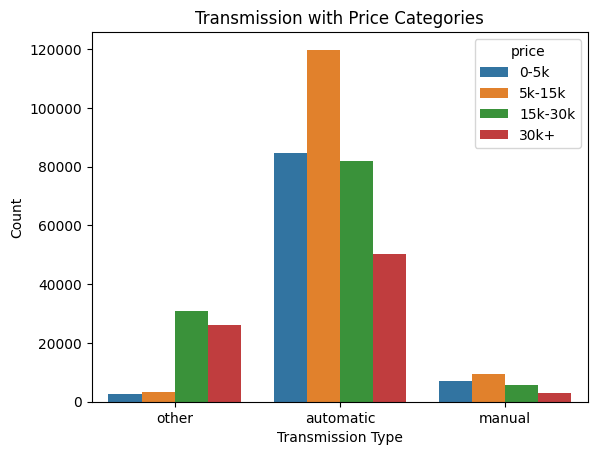

In [6]:
# Create bins for 'price' to use as a categorical hue
price_bins = pd.cut(df['price'], bins=[0, 5000, 15000, 30000, np.inf],
                    labels=['0-5k', '5k-15k', '15k-30k', '30k+'], right=False)

sns.countplot(x='transmission', data=df, hue=price_bins)
plt.title('Transmission with Price Categories')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

In [7]:
df['VIN'] = df['VIN'].fillna("unknown")

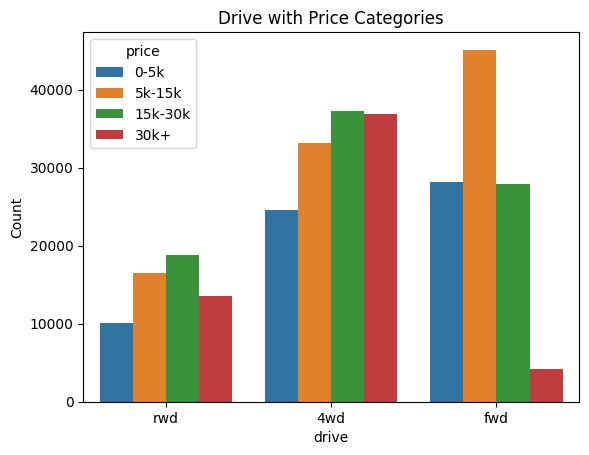

In [8]:
sns.countplot(x='drive', data=df, hue=price_bins)
plt.title('Drive with Price Categories')
plt.xlabel('drive')
plt.ylabel('Count')
plt.show()

**Drop VIN field. The Value of VIN is immaterial here.**

In [9]:
df.drop(columns=['VIN'], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  drive         296313 non-null  object 
 12  size          120519 non-null  object 
 13  type          334022 non-null  object 
 14  paint_color   296677 non-null  object 
 15  state         426880 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 52.1+ MB


**We have large number of missing values in:**

size

paint_color

In [13]:
for col in ['manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'drive','cylinders']:
    print(df[col].value_counts())
    print("Total Nulls:",df[col].isnull().sum())
    print("\n")

manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln             4220
volvo               3374
mitsubishi          3292
mini                2376
pontiac             2288
rover               2113
jaguar              1946
porsche             1384
mercury             1184
saturn              1090
alfa-romeo           897
tesla                868
fiat                 792
harley-davidson      153
ferrari               95
datsun                63
aston-martin

**Dropping null values columns which have less then 5% null values.**

It will clean NaN from columns:

manufacturer

year

model

fuel

odometer

title_status

transmission

In [15]:
for column in df.columns:
    null_percentage = (df[column].isna().sum() / len(df)) * 100
    print(f"Column '{column}': {null_percentage:.2f}% null values")
    if null_percentage < 5 and null_percentage > 0: # Only drop if there are nulls and percentage is below threshold
        # print(f"Dropping nulls for column '{column}' as percentage is {null_percentage:.2f}% of total rows.")
        df.dropna(subset=[column], inplace=True)
        # print(f"DataFrame size after dropping nulls in '{column}': {len(df)} rows")

print('\nFinal DataFrame info after automated null dropping:')
df.info()

Column 'region': 0.00% null values
Column 'price': 0.00% null values
Column 'year': 0.28% null values
Column 'manufacturer': 3.86% null values
Column 'model': 1.27% null values
Column 'condition': 40.68% null values
Column 'cylinders': 41.32% null values
Column 'fuel': 0.63% null values
Column 'odometer': 0.89% null values
Column 'title_status': 1.69% null values
Column 'transmission': 0.39% null values
Column 'drive': 29.54% null values
Column 'size': 71.18% null values
Column 'type': 21.21% null values
Column 'paint_color': 28.87% null values
Column 'state': 0.00% null values

Final DataFrame info after automated null dropping:
<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        389604 non-null  object 
 1   price         389604 non-null  int64  
 2   year          389604 non-null  float64
 3   manufacturer  389604 non-null 

Start with filling up rest of the columns having nulls with value unknown

In [16]:
df['condition'] = df['condition'].fillna("unknown")
df['cylinders'] = df['cylinders'].fillna("unknown")
df['drive'] = df['drive'].fillna("unknown")
df['type'] = df['type'].fillna("unknown")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        389604 non-null  object 
 1   price         389604 non-null  int64  
 2   year          389604 non-null  float64
 3   manufacturer  389604 non-null  object 
 4   model         389604 non-null  object 
 5   condition     389604 non-null  object 
 6   cylinders     389604 non-null  object 
 7   fuel          389604 non-null  object 
 8   odometer      389604 non-null  float64
 9   title_status  389604 non-null  object 
 10  transmission  389604 non-null  object 
 11  drive         389604 non-null  object 
 12  size          112273 non-null  object 
 13  type          389604 non-null  object 
 14  paint_color   277110 non-null  object 
 15  state         389604 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 50.5+ MB


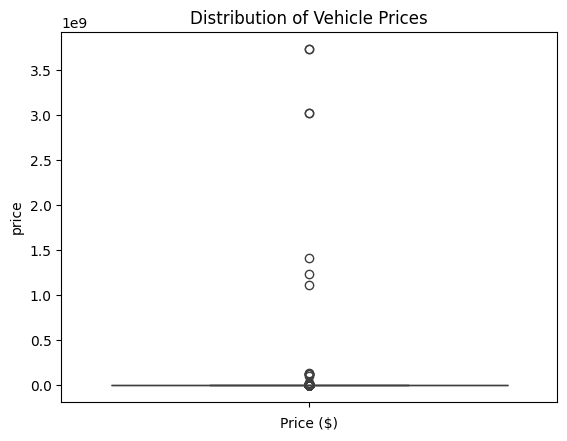

In [18]:
sns.boxplot(df['price'])
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price ($)')
plt.show()

Above plot shows there are lot of outliers in 'price' column

**Finding and removing outliers in 'Price'**

In [19]:
print(df['price'].describe())
print('\nQuantiles:')
print(df['price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

count    3.896040e+05
mean     6.395528e+04
std      1.144865e+07
min      0.000000e+00
25%      5.995000e+03
50%      1.399500e+04
75%      2.659000e+04
max      3.736929e+09
Name: price, dtype: float64

Quantiles:
0.01        0.00
0.05        0.00
0.25     5995.00
0.50    13995.00
0.75    26590.00
0.95    43987.85
0.99    64999.00
Name: price, dtype: float64


In [20]:
lower_bound = 400
upper_bound = df['price'].quantile(0.99)

df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

print(f"Original DataFrame size: {len(df)} rows")
print(f"Cleaned DataFrame size: {len(df_cleaned)} rows")
print(f"Number of outliers removed: {len(df) - len(df_cleaned)} rows")

print('\nDescriptive statistics of price after outlier removal:')
print(df_cleaned['price'].describe())

df_clean2 = df_cleaned

Original DataFrame size: 389604 rows
Cleaned DataFrame size: 350510 rows
Number of outliers removed: 39094 rows

Descriptive statistics of price after outlier removal:
count    350510.000000
mean      18588.472586
std       13107.972797
min         400.000000
25%        7750.000000
50%       15899.000000
75%       27590.000000
max       64999.000000
Name: price, dtype: float64


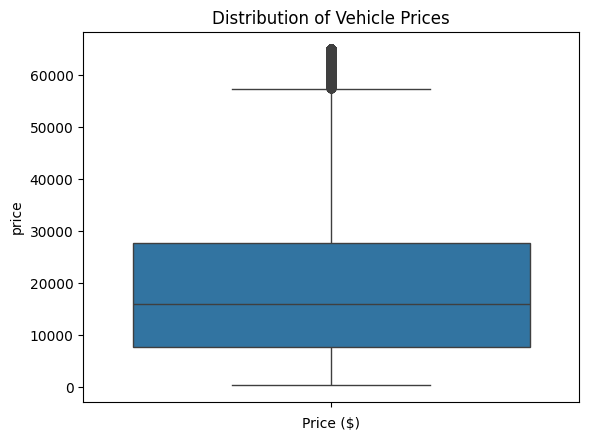

In [21]:
sns.boxplot(df_cleaned['price'])
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price ($)')
plt.show()

In [22]:
df_cleaned[['odometer']].describe()

,odometer
count,3.505100e+05
mean,9.772680e+04
std,1.786554e+05
min,0.000000e+00
25%,3.924650e+04
50%,8.860200e+04
75%,1.362240e+05
max,1.000000e+07


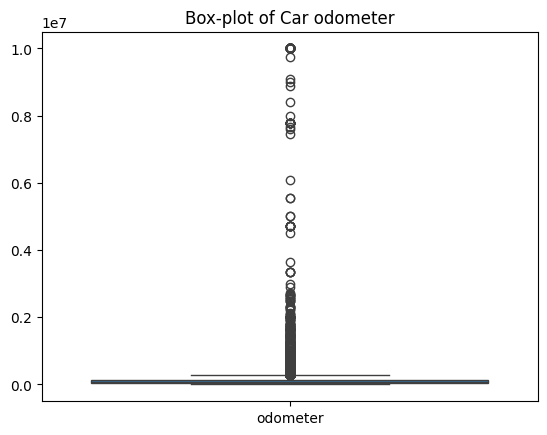

In [23]:
sns.boxplot(df_cleaned[['odometer']])
plt.title('Box-plot of Car odometer')
plt.show()

We need to remove outliers in 'odometer' as well

In [24]:
lower_bound = 100
upper_bound = df['odometer'].quantile(0.99)

df_cleaned = df_cleaned[(df_cleaned['odometer'] >= lower_bound) & (df_cleaned['odometer'] <= upper_bound)].copy()

print('\nDescriptive statistics of odometer after outlier removal:')
print(df_cleaned['odometer'].describe())


Descriptive statistics of odometer after outlier removal:
count    343713.000000
mean      92363.829026
std       59794.422172
min         100.000000
25%       39980.000000
50%       88470.000000
75%      135000.000000
max      267842.000000
Name: odometer, dtype: float64


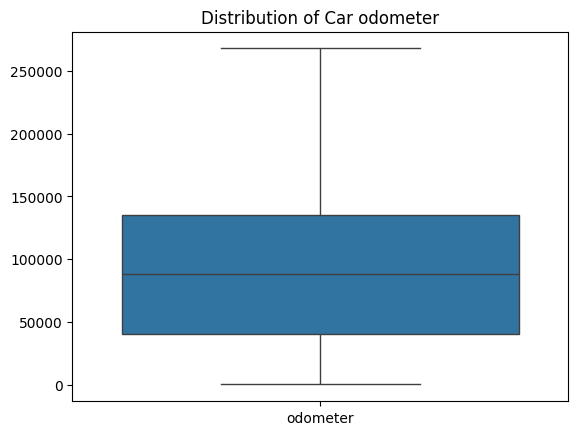

In [25]:
sns.boxplot(df_cleaned[['odometer']])
plt.title('Distribution of Car odometer')
plt.show()

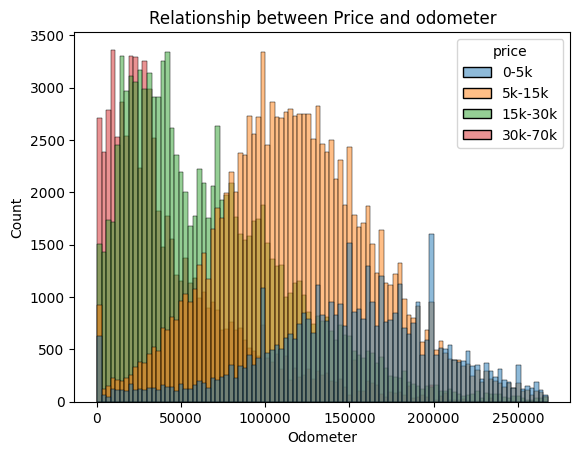

In [26]:
price_bins = pd.cut(df_cleaned['price'], bins=[0, 5000, 15000, 30000, 70000],
                    labels=['0-5k', '5k-15k', '15k-30k', '30k-70k'], right=False)
sns.histplot(data=df_cleaned, x='odometer', hue=price_bins)
plt.title('Relationship between Price and odometer')
plt.xlabel('Odometer')
plt.ylabel('Count')
plt.show()

'Year' itself does not provide much value. But if we calculate the car age from year, it can provide useful insight.

In [27]:
# Adding car_age
current_year = 2026
df_cleaned['car_age'] = current_year - df_cleaned['year']
df_cleaned.drop(columns=['year'], inplace=True)

Text(0, 0.5, 'Frequency')

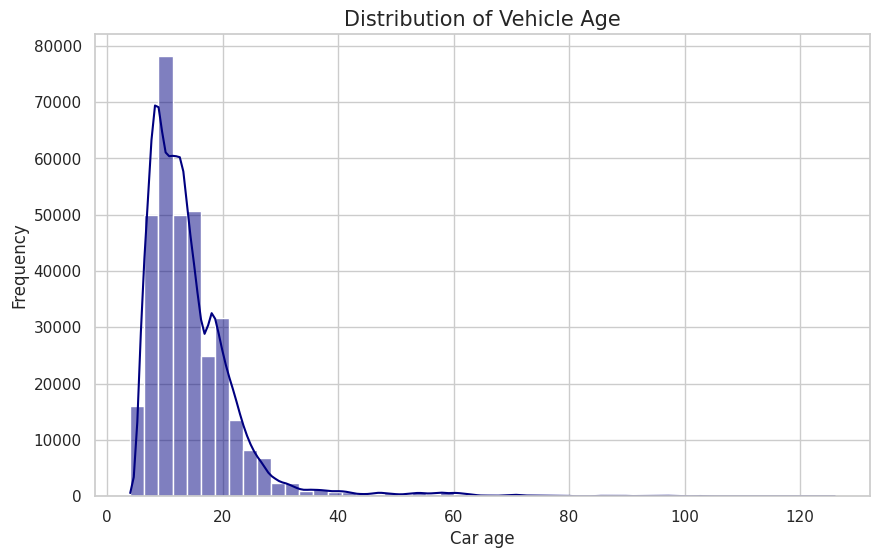

In [28]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['car_age'], bins=50, kde=True, color='navy')

# Add labels and title
plt.title('Distribution of Vehicle Age', fontsize=15)
plt.xlabel('Car age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

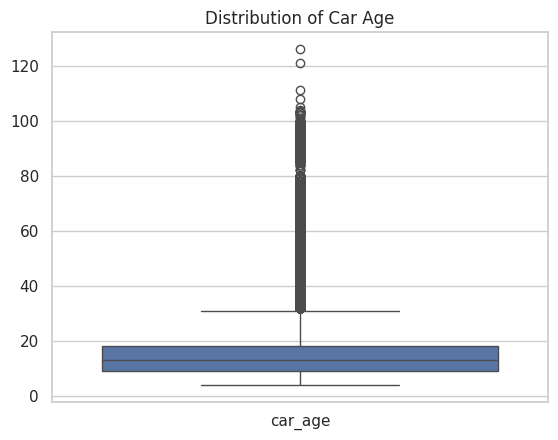

In [29]:
sns.boxplot(df_cleaned[['car_age']])
plt.title('Distribution of Car Age')
plt.show()

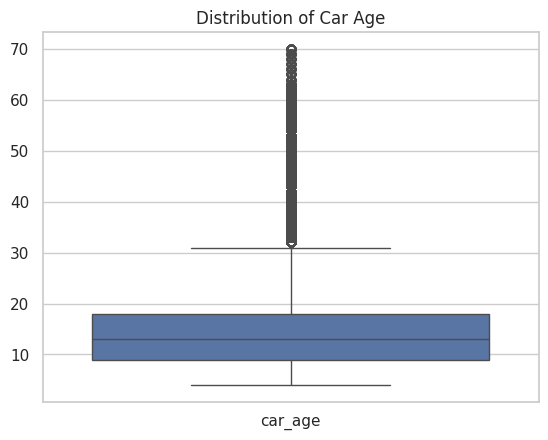

In [30]:
upper_bound = 70
df_cleaned = df_cleaned[df_cleaned['car_age'] <= upper_bound].copy()
sns.boxplot(df_cleaned[['car_age']])
plt.title('Distribution of Car Age')
plt.show()

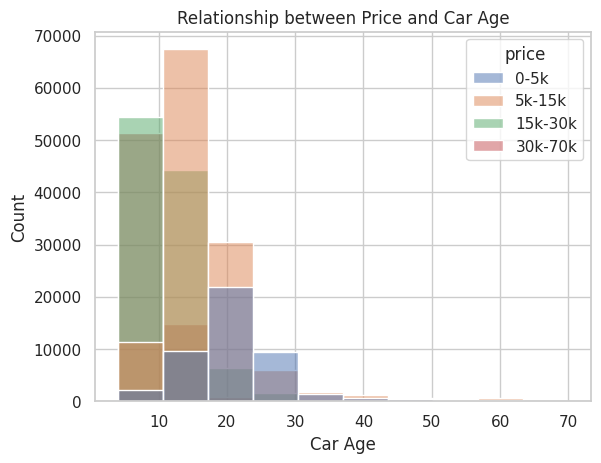

In [31]:
price_bins = pd.cut(df_cleaned['price'], bins=[0, 5000, 15000, 30000, 70000],
                    labels=['0-5k', '5k-15k', '15k-30k', '30k-70k'], right=False)
sns.histplot(data=df_cleaned, x='car_age', hue=price_bins, bins=10)
plt.title('Relationship between Price and Car Age')
plt.xlabel('Car Age')
plt.ylabel('Count')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

Let us find out the distribution of 'price' to find out if we need any more preprocessing on 'price'

Text(0, 0.5, 'Frequency')

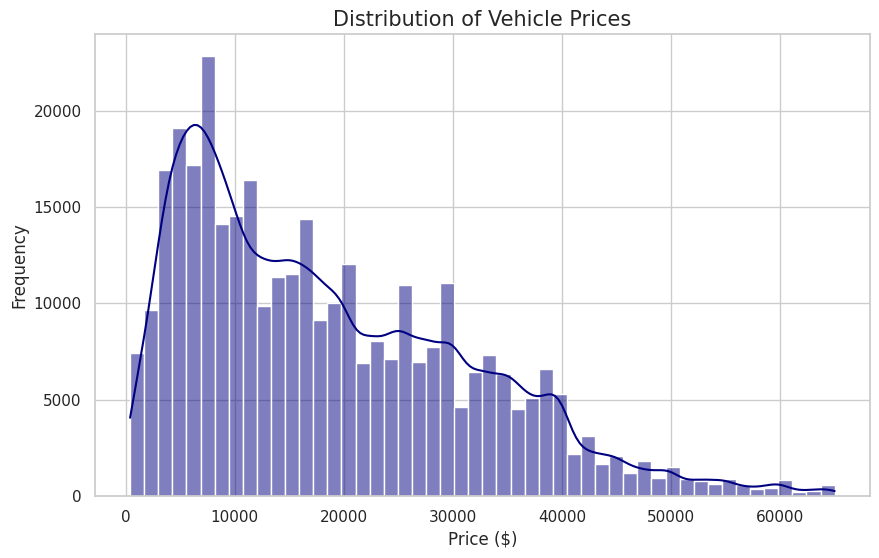

In [32]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['price'], bins=50, kde=True, color='navy')

# Add labels and title
plt.title('Distribution of Vehicle Prices', fontsize=15)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

The distribution is right skewed, hence taking log will be a good idea

In [33]:
df_cleaned['log_price'] = np.log(df_cleaned['price']).replace([np.inf, -np.inf], np.nan)
df_cleaned.drop(columns=['price'], inplace=True)
df_cleaned.dropna(subset=['log_price'], inplace=True)

Text(0, 0.5, 'Frequency')

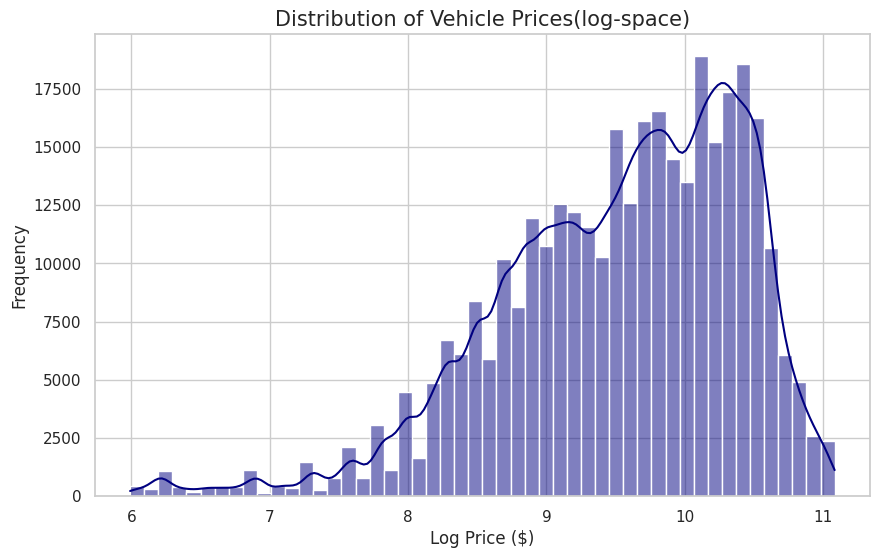

In [34]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['log_price'], bins=50, kde=True, color='navy')

# Add labels and title
plt.title('Distribution of Vehicle Prices(log-space)', fontsize=15)
plt.xlabel('Log Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

In [35]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342807 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        342807 non-null  object 
 1   manufacturer  342807 non-null  object 
 2   model         342807 non-null  object 
 3   condition     342807 non-null  object 
 4   cylinders     342807 non-null  object 
 5   fuel          342807 non-null  object 
 6   odometer      342807 non-null  float64
 7   title_status  342807 non-null  object 
 8   transmission  342807 non-null  object 
 9   drive         342807 non-null  object 
 10  size          97955 non-null   object 
 11  type          342807 non-null  object 
 12  paint_color   248458 non-null  object 
 13  state         342807 non-null  object 
 14  car_age       342807 non-null  float64
 15  log_price     342807 non-null  float64
dtypes: float64(3), object(13)
memory usage: 44.5+ MB


Taking log of car age will also be a good idea

In [36]:
df_cleaned['log_age'] = np.log(df_cleaned['car_age']).replace([np.inf, -np.inf], np.nan)
df_cleaned.drop(columns=['car_age'], inplace=True)
df_cleaned.dropna(subset=['log_age'], inplace=True)

Text(0, 0.5, 'Frequency')

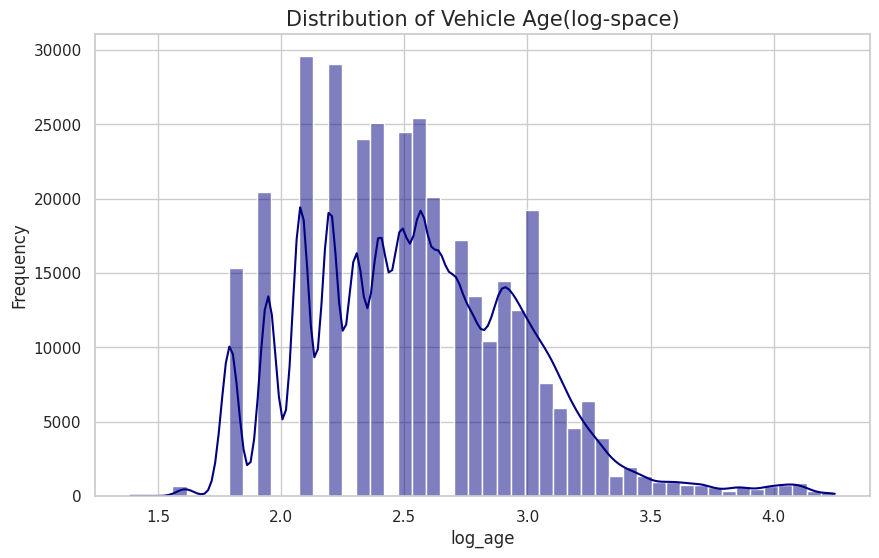

In [37]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['log_age'], bins=50, kde=True, color='navy')

# Add labels and title
plt.title('Distribution of Vehicle Age(log-space)', fontsize=15)
plt.xlabel('log_age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

Lets also check odometer's distribution

Text(0, 0.5, 'Frequency')

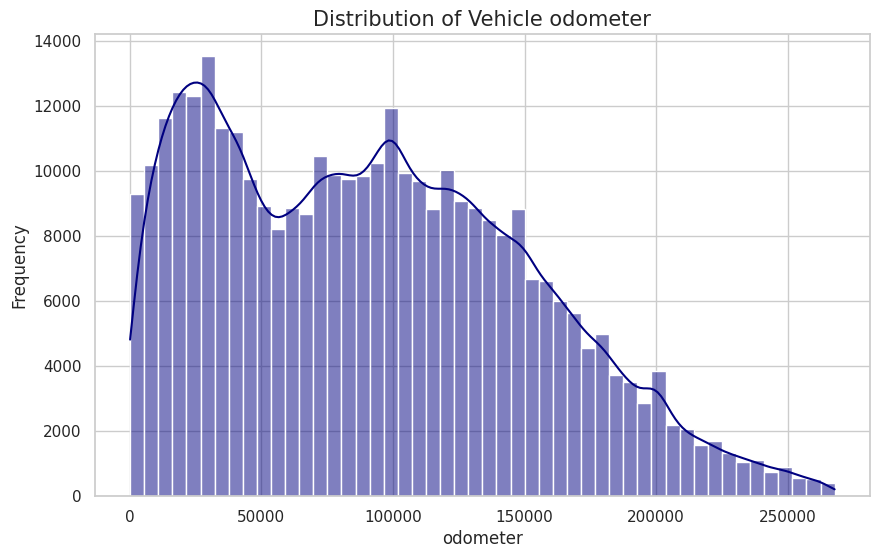

In [38]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['odometer'], bins=50, kde=True, color='navy')

# Add labels and title
plt.title('Distribution of Vehicle odometer', fontsize=15)
plt.xlabel('odometer', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

In [39]:

df_cleaned['log_odometer'] = np.log(df_cleaned['odometer']).replace([np.inf, -np.inf], np.nan)
df_cleaned.drop(columns=['odometer'], inplace=True)
df_cleaned.dropna(subset=['log_odometer'], inplace=True)


Text(0, 0.5, 'Frequency')

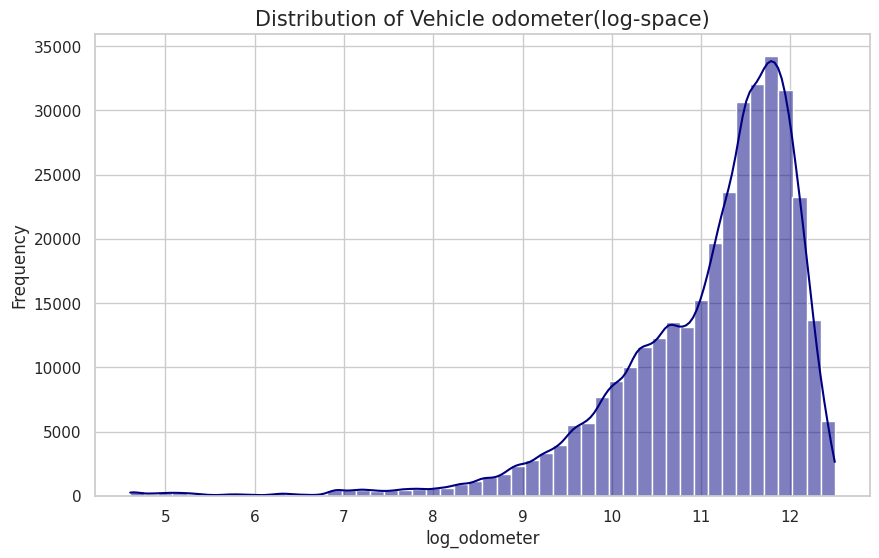

In [40]:
# Set the style
sns.set_theme(style="whitegrid")

# Create the histogram with a Kernel Density Estimate (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['log_odometer'], bins=50, kde=True, color='navy')

# Add labels and title
plt.title('Distribution of Vehicle odometer(log-space)', fontsize=15)
plt.xlabel('log_odometer', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

**Frequency analysis done earlier revealed that columns like model and manufacturer has very high cardinality**

In [41]:
for col in ['manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission']:
    print(df_cleaned[col].value_counts())
    print("\n")

manufacturer
ford               58188
chevrolet          45031
toyota             28998
honda              18454
nissan             16013
jeep               15927
ram                14259
gmc                13808
bmw                12810
dodge              10736
mercedes-benz       9293
hyundai             8710
subaru              8414
volkswagen          8177
lexus               7267
kia                 7023
audi                6778
cadillac            5999
acura               5391
chrysler            5182
buick               4792
mazda               4688
infiniti            4300
lincoln             3747
volvo               2959
mitsubishi          2786
mini                2117
pontiac             2056
jaguar              1742
rover               1557
porsche             1106
saturn              1009
mercury              998
alfa-romeo           824
tesla                743
fiat                 731
harley-davidson      106
datsun                58
aston-martin          11
land rover  

**Drop manufacturers with very less entries**

In [42]:
# List of manufacturers to drop
manufacturers_to_drop = ['land rover', 'datsun', 'aston-martin', 'harley-davidson', 'ferrari']

# Drop rows with specified manufacturers
df_cleaned = df_cleaned[~df_cleaned['manufacturer'].isin(manufacturers_to_drop)]

In [43]:
df_cleaned['model'].nunique()

19333

Let's try to reduce the cardinality of model column without loosing the data in the column. Let's create a new category "other" for models which have very less count in this big dataset.

In [44]:
rare_models=[]
for model, count in df_cleaned['model'].value_counts().items():
    if count < 50:
        rare_models.append(model)
print(len(rare_models))

18261


In [45]:
# for model in rare_models:
#     df_cleaned['model'] = df_cleaned['model'].replace(model, 'other')
df_cleaned.loc[df_cleaned['model'].isin(rare_models), 'model'] = 'other'

In [46]:
df_cleaned['model'].nunique()

1073

In [47]:
df_cleaned.shape

(342613, 16)

In [48]:
print(f"Total loss : {((426880 - df_cleaned.shape[0])/426880)*100:.2f}%")

Total loss : 19.74%


In [49]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342613 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        342613 non-null  object 
 1   manufacturer  342613 non-null  object 
 2   model         342613 non-null  object 
 3   condition     342613 non-null  object 
 4   cylinders     342613 non-null  object 
 5   fuel          342613 non-null  object 
 6   title_status  342613 non-null  object 
 7   transmission  342613 non-null  object 
 8   drive         342613 non-null  object 
 9   size          97887 non-null   object 
 10  type          342613 non-null  object 
 11  paint_color   248323 non-null  object 
 12  state         342613 non-null  object 
 13  log_price     342613 non-null  float64
 14  log_age       342613 non-null  float64
 15  log_odometer  342613 non-null  float64
dtypes: float64(3), object(13)
memory usage: 44.4+ MB


In [50]:
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

# Define numeric and categorical columns

# 'log_price' should be excluded from numeric_features as it is the target variable (y)
numeric_features = ['log_odometer', 'log_age']
categorical_features = ['manufacturer', 'model', 'condition', 'fuel', 'cylinders',
                        'title_status', 'transmission', 'drive', 'type', 'region', 'state','size' ,'paint_color' ]

# Define transformer and column mapping
preprocessor = ColumnTransformer(
    transformers=[
                ('encode', TargetEncoder(), categorical_features)
    ],
    remainder='passthrough'
)


Let us get the pre-processed dataframe.

In [51]:
df_cleaned_preprocessed = pd.DataFrame(preprocessor.fit_transform(df_cleaned, df_cleaned['log_price']), columns=preprocessor.get_feature_names_out())
corr_to_logPrice = df_cleaned_preprocessed.corr()['remainder__log_price']
# corr_to_logPrice.sort()
print(corr_to_logPrice)

encode__manufacturer       0.310887
encode__model              0.571553
encode__condition          0.271890
encode__fuel               0.266482
encode__cylinders          0.258374
encode__title_status       0.116372
encode__transmission       0.347748
encode__drive              0.247669
encode__type               0.350682
encode__region             0.245877
encode__state              0.147947
encode__size               0.216681
encode__paint_color        0.190351
remainder__log_price       1.000000
remainder__log_age        -0.597811
remainder__log_odometer   -0.464382
Name: remainder__log_price, dtype: float64


In [52]:
df_significant = df_cleaned_preprocessed

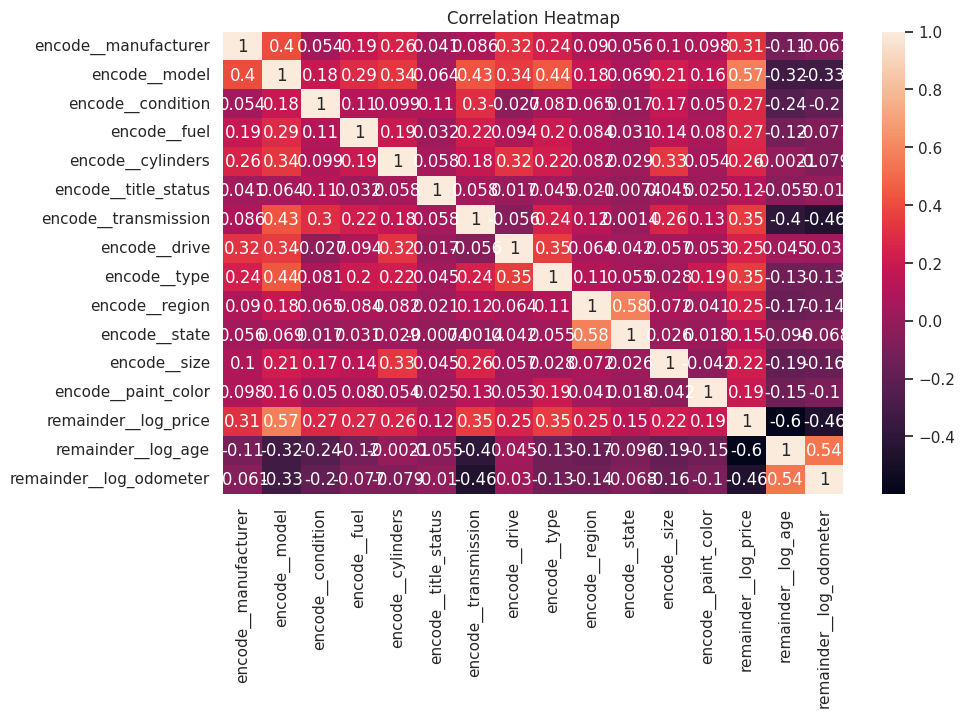

In [53]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_significant.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Get the column names back after pre-processing

In [54]:
rename_mappings = {}
for col in df_significant.columns:
  if('remainder__' in col):
    rename_mappings[col]=col.replace('remainder__', '')
  elif('encode__' in col):
    rename_mappings[col]=col.replace('encode__', '')

In [55]:
df_significant.rename(columns=rename_mappings, inplace=True)

In [56]:
df_significant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342613 entries, 0 to 342612
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   manufacturer  342613 non-null  float64
 1   model         342613 non-null  float64
 2   condition     342613 non-null  float64
 3   fuel          342613 non-null  float64
 4   cylinders     342613 non-null  float64
 5   title_status  342613 non-null  float64
 6   transmission  342613 non-null  float64
 7   drive         342613 non-null  float64
 8   type          342613 non-null  float64
 9   region        342613 non-null  float64
 10  state         342613 non-null  float64
 11  size          342613 non-null  float64
 12  paint_color   342613 non-null  float64
 13  log_price     342613 non-null  float64
 14  log_age       342613 non-null  float64
 15  log_odometer  342613 non-null  float64
dtypes: float64(16)
memory usage: 41.8 MB


In [57]:
df_significant.head()

,manufacturer,model,condition,fuel,cylinders,title_status,transmission,drive,type,region,state,size,paint_color,log_price,log_age,log_odometer
0,9.834660,10.468737,9.692080,9.434694,9.766847,9.541376,10.196883,9.492683,10.081471,10.170533,9.720385,9.637582,9.755922,10.421984,2.484907,10.966870
1,9.555261,9.848466,9.691305,9.433157,9.765361,9.539661,10.198431,9.494217,10.081787,10.140073,9.723976,9.637269,9.431076,10.025263,2.772589,11.173655
2,9.557767,10.426030,9.693311,9.435360,9.766514,9.541967,10.198496,9.494151,10.078563,10.155661,9.729608,9.638343,9.572757,10.586332,1.791759,9.860580
3,9.464164,10.454970,9.694508,9.434571,9.762426,9.541411,10.200335,9.494229,10.080948,10.185230,9.722076,9.638070,9.574239,10.341420,2.197225,10.624347
4,9.617070,9.712576,9.375083,9.434694,9.489115,9.541376,9.406100,9.667915,9.908411,10.170533,9.720385,9.379970,9.716003,9.615805,2.564949,11.759786


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Separate features (X) and target (y)
X = df_significant.drop(columns=['log_price'], axis=1)
y = df_significant['log_price']

# test train split the cleaned dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Build pipeline for RIDGR REGRESSION
ridge_pipeline = Pipeline([
                     ('scaler', StandardScaler()),
                    ('ridge', Ridge(alpha=1.0))
                    ])

ridge_pipeline.fit(X_train, y_train)

y_pred_log = ridge_pipeline.predict(X_test)
mse_log = mean_squared_error(y_test, y_pred_log)
print(f"Mean Squared Error (Log-Space): {mse_log:.4f}")
print(f"Model's R^2 score: {ridge_pipeline.score(X_test, y_test):.4f}")

Mean Squared Error (Log-Space): 0.3175
Model's R^2 score: 0.5918


In [60]:
mae_log = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log))
print(f"On average, the model's prediction is off by: ${mae_log:,.2f}")

On average, the model's prediction is off by: $5,701.37


In [61]:
# Now you can look at the coefficients or intercept
print(ridge_pipeline.named_steps['ridge'].coef_)
print(ridge_pipeline.named_steps['ridge'].intercept_)

[ 0.05673055  0.21815175  0.07535703  0.07096552  0.06509877  0.04754569
 -0.07424104  0.0816488   0.07297198  0.0591394   0.02180683  0.01288822
  0.03347762 -0.35825376 -0.1264141 ]
9.526451382155242


In [62]:
# RIDGE(1.0) with polynomial features degree=2
from sklearn.preprocessing import PolynomialFeatures

ridgePoly_pipeline = Pipeline([
                               ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                               ('scaler', StandardScaler()),
                               ('ridge', Ridge(alpha=1.0))
                              ])

ridgePoly_pipeline

ridgePoly_pipeline.fit(X_train, y_train)

y_pred_log2 = ridgePoly_pipeline.predict(X_test)
mse_log2 = mean_squared_error(y_test, y_pred_log2)
print(f"Mean Squared Error (Log-Space): {mse_log2:.4f}")
print(f"Model's R^2 score: {ridgePoly_pipeline.score(X_test, y_test):.4f}")

Mean Squared Error (Log-Space): 0.2610
Model's R^2 score: 0.6644


In [63]:
# Now you can look at the coefficients or intercept
# print(ridgePoly_pipeline.named_steps['ridge'].get_feature_names_out())
# print(len(ridgePoly_pipeline.named_steps['poly'].get_feature_names_out()))

In [64]:
mae_log2 = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log2))
print(f"On average, the model's prediction is off by: ${mae_log2:,.2f}")

On average, the model's prediction is off by: $4,690.60


In [65]:
# RIDGE(1.0) with polynomial features degree=3
from sklearn.preprocessing import PolynomialFeatures

ridge1Poly3_pipeline = Pipeline([
                                  ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                                  ('scaler', StandardScaler()),
                                  ('ridge', Ridge(alpha=1.0))
                                ])

ridge1Poly3_pipeline.fit(X_train, y_train)

y_pred_log3 = ridge1Poly3_pipeline.predict(X_test)
mse_log3 = mean_squared_error(y_test, y_pred_log3)
print(f"Mean Squared Error (Log-Space): {mse_log3:.4f}")
print(f"Model's R^2 score: {ridge1Poly3_pipeline.score(X_test, y_test):.4f}")



Mean Squared Error (Log-Space): 0.2456
Model's R^2 score: 0.6842


In [66]:
mae_log3 = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log3))
print(f"On average, the model's prediction is off by: ${mae_log3:,.2f}")


On average, the model's prediction is off by: $4,421.79


In [67]:
# GridSearchCV with k-fold validation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

aplha_values = [0.01, 0.1, 1, 10, 100]

model_finder = GridSearchCV(ridge1Poly3_pipeline,
                            param_grid={'ridge__alpha': aplha_values},
                            scoring = 'r2',
                            cv=5)

model_finder.fit(X_train, y_train)

best_model = model_finder.best_estimator_

best_model.fit(X_train, y_train)
y_pred_log4 = best_model.predict(X_test)
mse_log4 = mean_squared_error(y_test, y_pred_log4)
print(f"Mean Squared Error (Log-Space): {mse_log4:.4f}")
print(f"Model's R^2 score: {best_model.score(X_test, y_test):.4f}")



Mean Squared Error (Log-Space): 0.2366
Model's R^2 score: 0.6958


In [68]:
mae_log4 = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_log4))
# error_in_pred4 = np.expm1(mae_log5)
print(f"On average, the model's prediction is off by: ${mae_log4:,.2f}")

On average, the model's prediction is off by: $4,232.35


In [69]:
model_finder.cv_results_

{'mean_fit_time': array([12.81229076, 11.6014132 , 12.158147  , 12.88820405, 12.42829566]),
 'std_fit_time': array([2.05891589, 0.10612749, 0.51206993, 0.09433596, 0.34273676]),
 'mean_score_time': array([0.89523005, 0.71441293, 0.72682457, 0.71720686, 0.83323636]),
 'std_score_time': array([0.04601522, 0.01109571, 0.01369976, 0.00893688, 0.09620881]),
 'param_ridge__alpha': masked_array(data=[0.01, 0.1, 1.0, 10.0, 100.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'ridge__alpha': 0.01},
  {'ridge__alpha': 0.1},
  {'ridge__alpha': 1},
  {'ridge__alpha': 10},
  {'ridge__alpha': 100}],
 'split0_test_score': array([0.69569651, 0.68977803, 0.68427776, 0.68029185, 0.67226859]),
 'split1_test_score': array([0.69848597, 0.69247768, 0.68715156, 0.68301032, 0.67403036]),
 'split2_test_score': array([0.69558117, 0.68994322, 0.68471201, 0.68063442, 0.67222413]),
 'split3_test_score': array([0.70037571, 0.69467048, 0.68909989, 0.68481345, 0.6771

In [70]:
best_model.get_params()

{'memory': None,
 'steps': [('poly', PolynomialFeatures(degree=3, include_bias=False)),
  ('scaler', StandardScaler()),
  ('ridge', Ridge(alpha=0.01))],
 'transform_input': None,
 'verbose': False,
 'poly': PolynomialFeatures(degree=3, include_bias=False),
 'scaler': StandardScaler(),
 'ridge': Ridge(alpha=0.01),
 'poly__degree': 3,
 'poly__include_bias': False,
 'poly__interaction_only': False,
 'poly__order': 'C',
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'ridge__alpha': 0.01,
 'ridge__copy_X': True,
 'ridge__fit_intercept': True,
 'ridge__max_iter': None,
 'ridge__positive': False,
 'ridge__random_state': None,
 'ridge__solver': 'auto',
 'ridge__tol': 0.0001}

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [71]:
eval_dictionary = {"ridgePipeline":mae_log, "ridgePoly_pipeline":mae_log2, "ridge1Poly3_pipeline":mae_log3, "model_finder":mae_log4}
#convert this dictionary to dataframe
eval_df = pd.DataFrame.from_dict(eval_dictionary, orient='index')

In [72]:
eval_df

,0
ridgePipeline,5701.371653
ridgePoly_pipeline,4690.600184
ridge1Poly3_pipeline,4421.787860
model_finder,4232.353163


In [73]:
eval_df.rename(columns={0: 'error in price prediction'}, inplace=True)
eval_df.index.name = 'model name'
display(eval_df)

,error in price prediction
model name,
ridgePipeline,5701.371653
ridgePoly_pipeline,4690.600184
ridge1Poly3_pipeline,4421.787860
model_finder,4232.353163


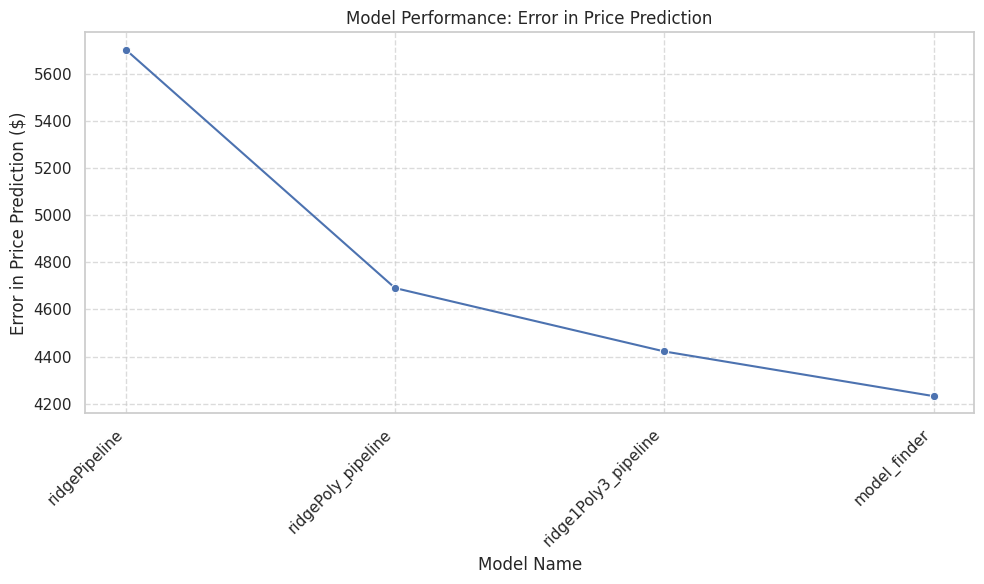

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_df.index, y='error in price prediction', data=eval_df, marker='o')
plt.title('Model Performance: Error in Price Prediction')
plt.xlabel('Model Name')
plt.ylabel('Error in Price Prediction ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**The above plot shows that the error in prediction decreased as we introduces polynomial features with higher degrees. And the error in prediction dropped even further when we performed "GridSearch" with K-fold cross-validation to find out the optimal value of hyperparameters(like alpha)**

**For the completion of the business and the data task at hand, we need to understand the importance of features or impact of features on the price.**

#### **Impact of original features using permutation importance**
We can find out which feature individually has highest impact on car price using "permutation importance"

In [78]:
from sklearn.inspection import permutation_importance

best_pipeline = Pipeline([('poly', PolynomialFeatures(degree=3, include_bias=False)),
                            ('scaler', StandardScaler()),
                            ('ridge', Ridge(alpha=0.01))
                          ])

best_pipeline.fit(X_train, y_train)
features = df_significant.drop(columns=['log_price'], axis=1).columns.tolist()
# Permutation importance
r = permutation_importance(best_pipeline, X_test[features], y_test, n_repeats=30, random_state=42)

# Sort the results by importance
sorted_idx = r.importances_mean.argsort()

/tmp/ipykernel_11702/3079033896.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(r.importances[sorted_idx].T,


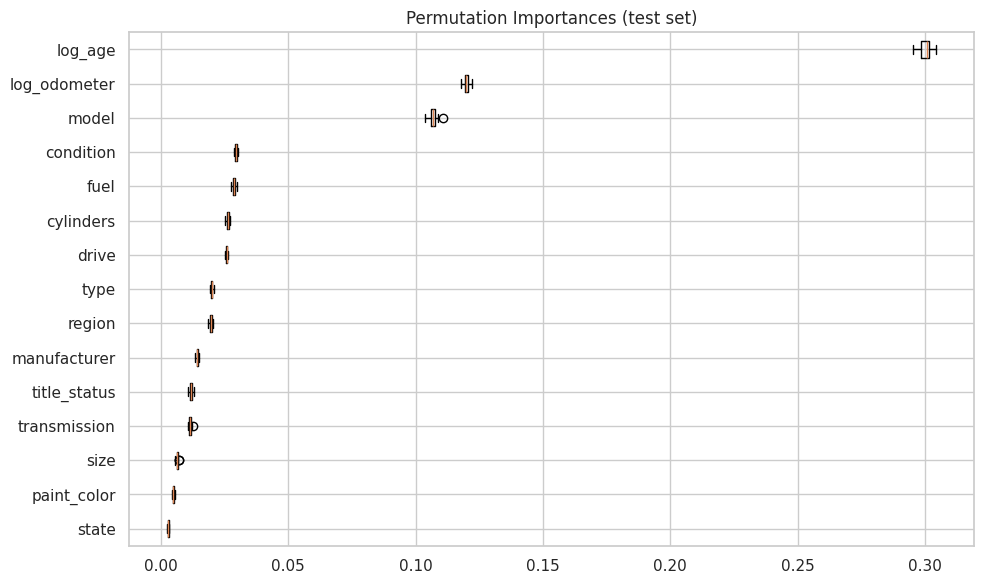

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(r.importances[sorted_idx].T,
           vert=False, labels=np.array(features)[sorted_idx])
ax.set_title("Permutation Importances (test set)")
fig.tight_layout()
plt.show()

#### **Insights from Permutation Importance:**

The plot clearly shows below three features impact price the most.

1.   log_age
2.   log_odometer
1.   model

Other features like condition, fuel, drive etc also impact the price. But when we use polynomial features, these features having little individual impact can create big impact on price when combined together





#### **Impact of higher degree features**

We need to find out the coefficients of the top 10 features having positive and negative impact on the price.

### Interpretation of Coefficients

*   **Positive Coefficients**: A positive coefficient indicates that as the value of that feature increases, the `log_price` (and thus the actual price) of the car tends to increase, assuming all other features remain constant.
*   **Negative Coefficients**: Conversely, a negative coefficient suggests that an increase in that feature's value is associated with a decrease in `log_price`.
*   **Magnitude of Coefficients**: The absolute magnitude of the coefficient reflects the strength of the relationship. Larger absolute values indicate a stronger impact on the price.

Since the numerical features (`odometer`, `car_age`) were `log1p` transformed and categorical features were `TargetEncoded`, the interpretation for interaction terms or transformed categorical values needs to consider these transformations. For target encoded features, a higher encoded value typically means that category was associated with higher prices in the training data. For log-transformed numerical features, the coefficient represents the change in log-price for a one-unit change in the log of the feature.

In [75]:
#Top 10 Features with positive coefficients

polynomial_feature_names = best_model.named_steps['poly'].get_feature_names_out()

# Get coefficients from the Ridge model
coefficients = best_model.named_steps['ridge'].coef_
features = df_significant.drop(columns=['log_price'], axis=1).columns.tolist()
# Create a DataFrame for better visualization and sorting
feature_importance = pd.DataFrame({'Feature': polynomial_feature_names, 'Coefficient': coefficients}).reset_index()

# Sort by the absolute value of coefficients to see the most impactful features
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

print("Top 10 Most Impactful Features and their Coefficients:")
display(feature_importance.head(10))

Top 20 Most Impactful Features and their Coefficients:


,index,Feature,Coefficient,Abs_Coefficient
16,16,manufacturer model,38.730553,38.730553
651,651,transmission^2 drive,37.228303,37.228303
734,734,type^2 size,31.915978,31.915978
36,36,model drive,30.527036,30.527036
797,797,size^2 log_age,29.795849,29.795849
260,260,model^2 transmission,29.339476,29.339476
501,501,fuel type^2,25.658938,25.658938
178,178,manufacturer fuel cylinders,25.457414,25.457414
538,538,cylinders^2 log_age,23.838737,23.838737
112,112,type log_age,23.658525,23.658525


The top ten features are all higher degree features. This means that certain combination of these features are impacting the car price.

So let us understand the encoding for all the categorial columns we got earlier after running the column transformer.

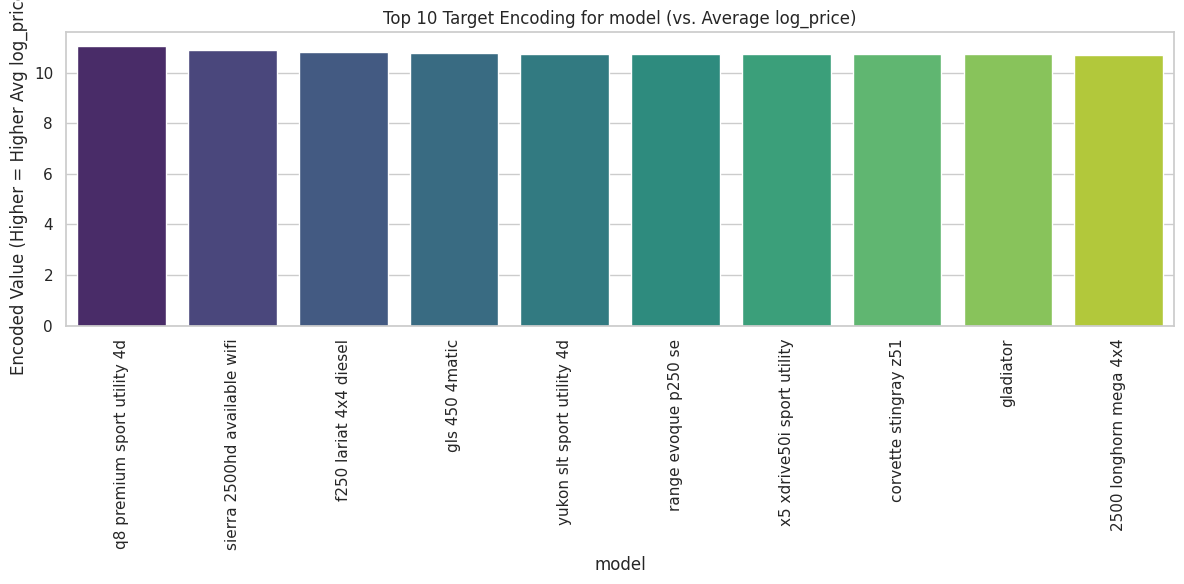

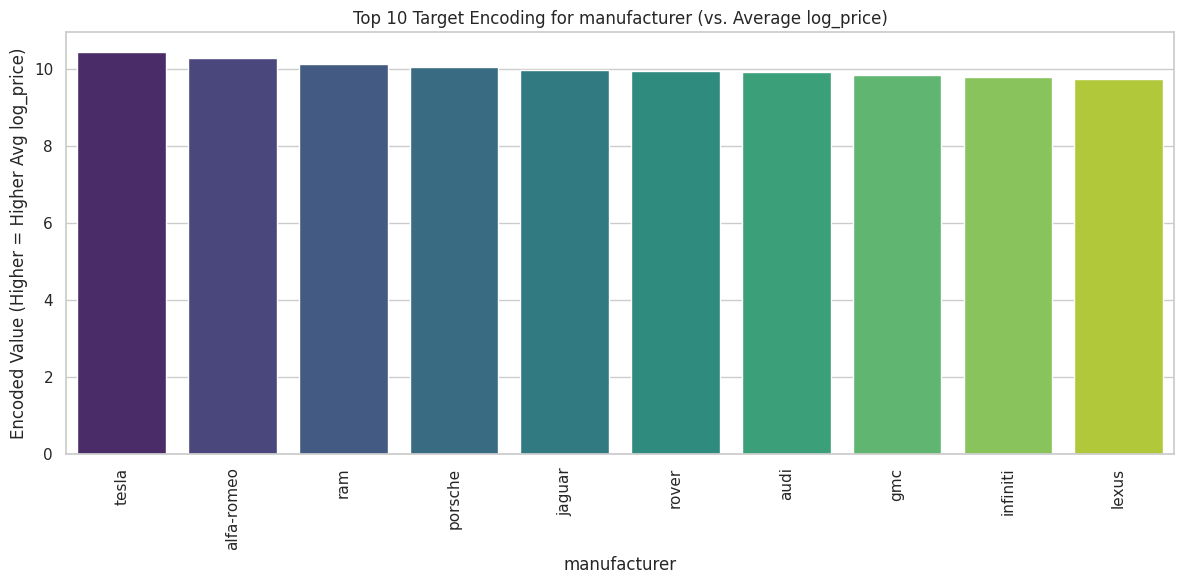

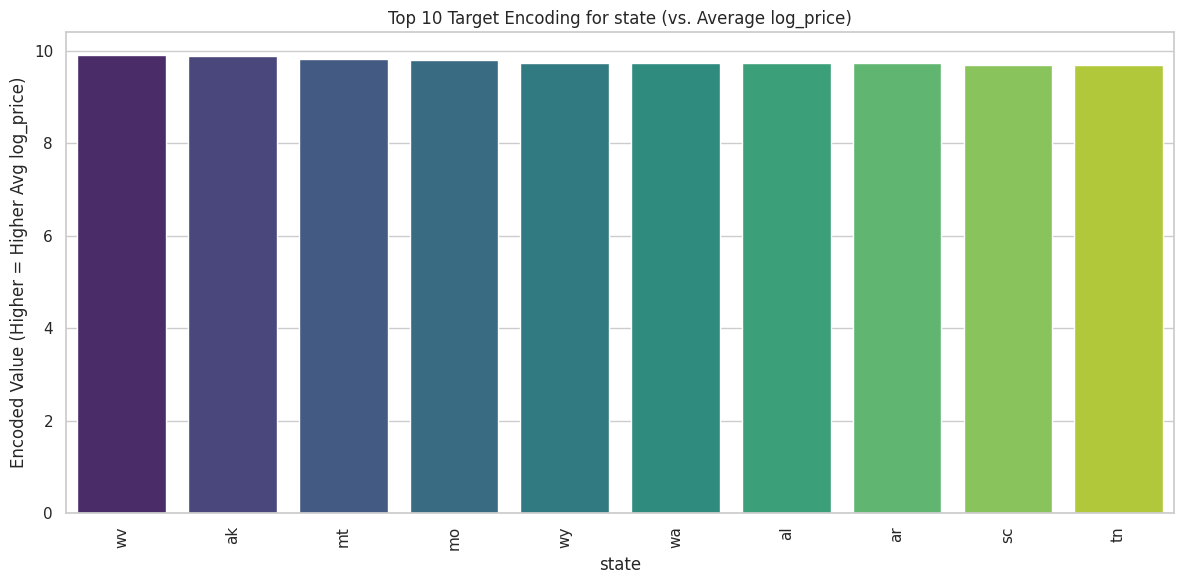

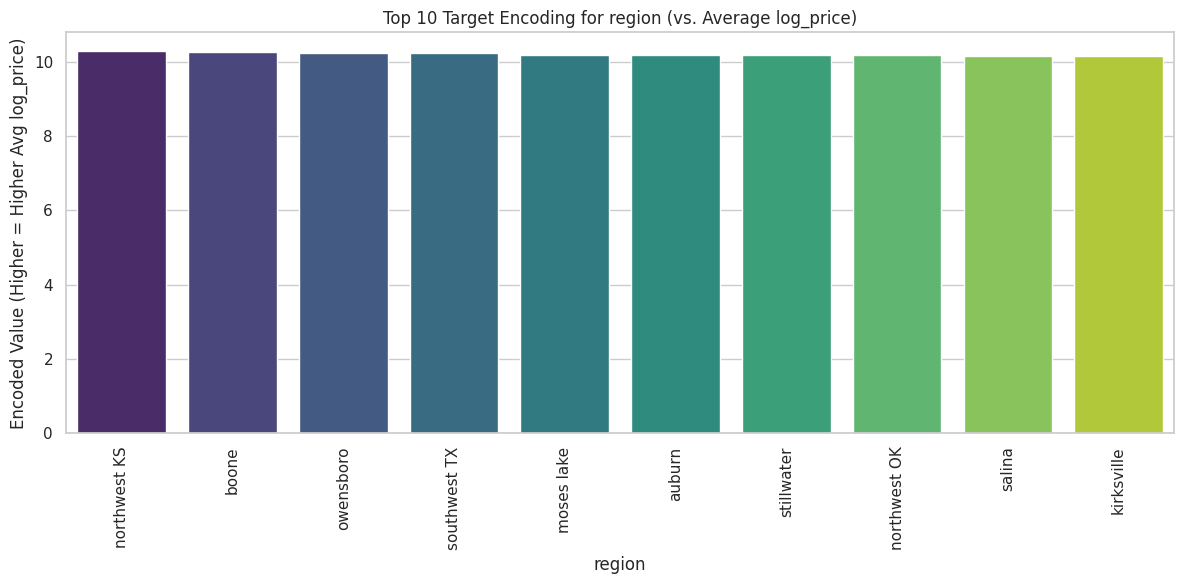

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

target_encoder = preprocessor.named_transformers_['encode']

columns_to_plot_top_n = ['model', 'manufacturer', 'state', 'region']

for feature in columns_to_plot_top_n:
    feature_index = categorical_features.index(feature)
    mapping = pd.Series(target_encoder.encodings_[feature_index], index=target_encoder.categories_[feature_index])

    # Sort and select top 10
    top_10_mapping = mapping.sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_10_mapping.index, y=top_10_mapping.values, hue=top_10_mapping.index, palette='viridis', legend=False)
    plt.title(f'Top 10 Target Encoding for {feature} (vs. Average log_price)')
    plt.xlabel(feature)
    plt.ylabel('Encoded Value (Higher = Higher Avg log_price)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

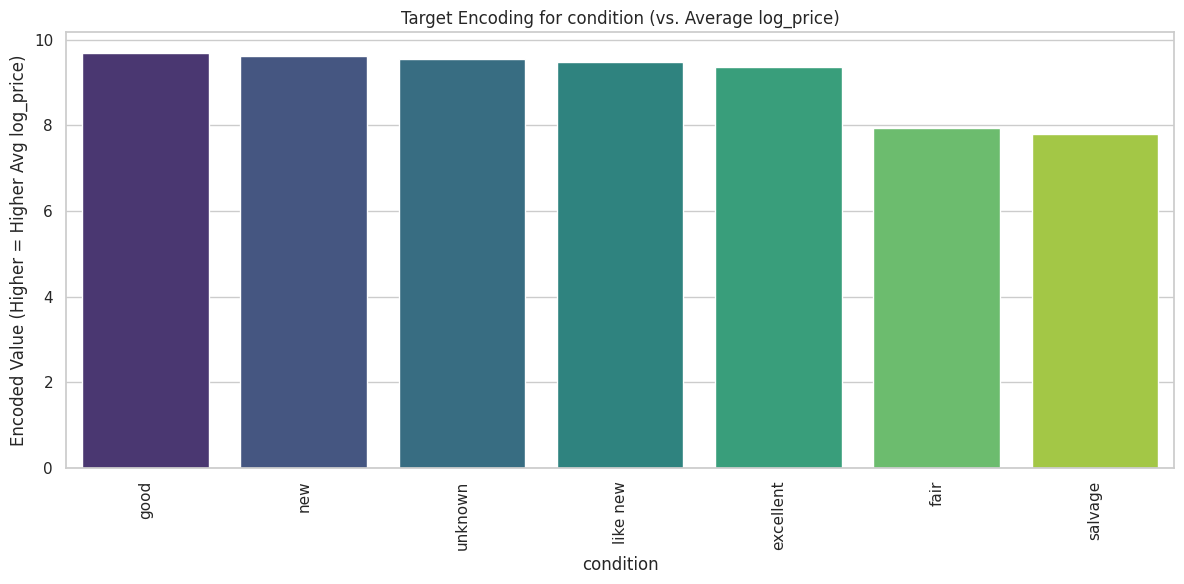

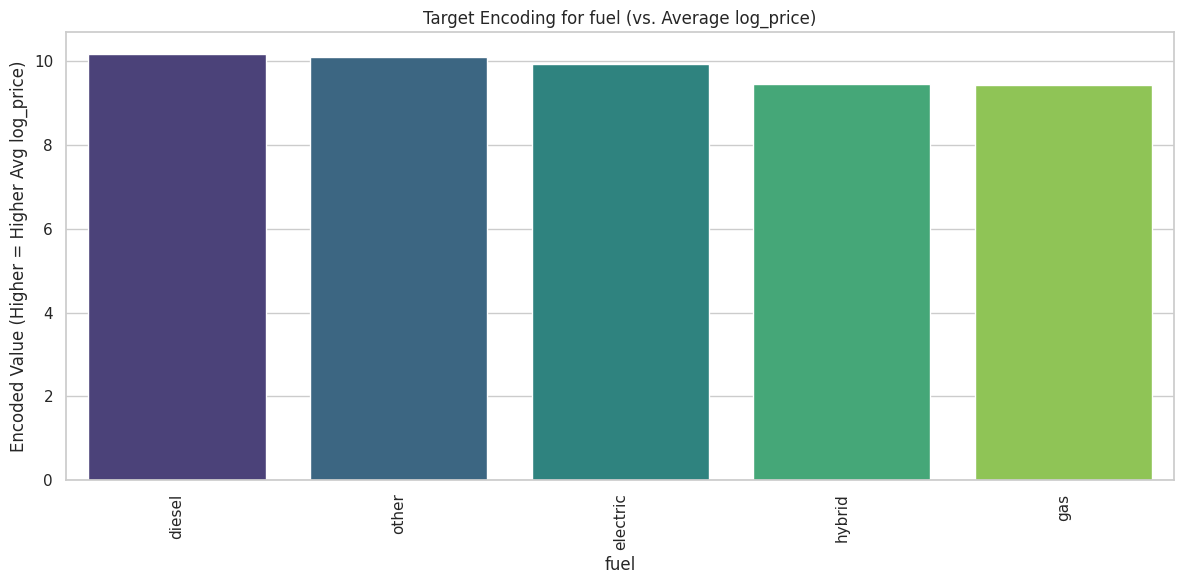

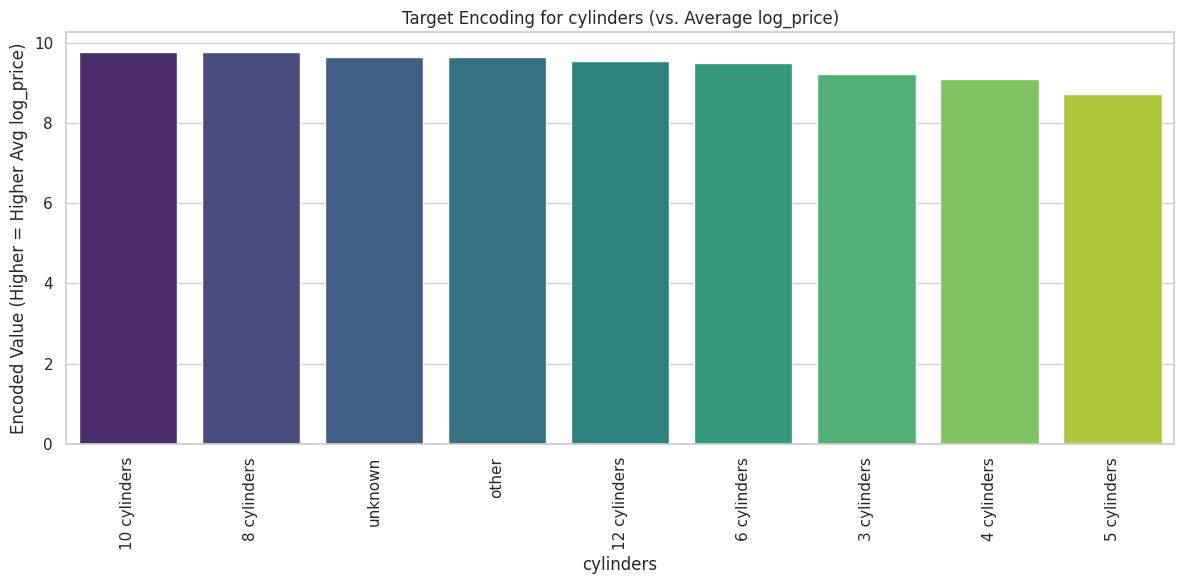

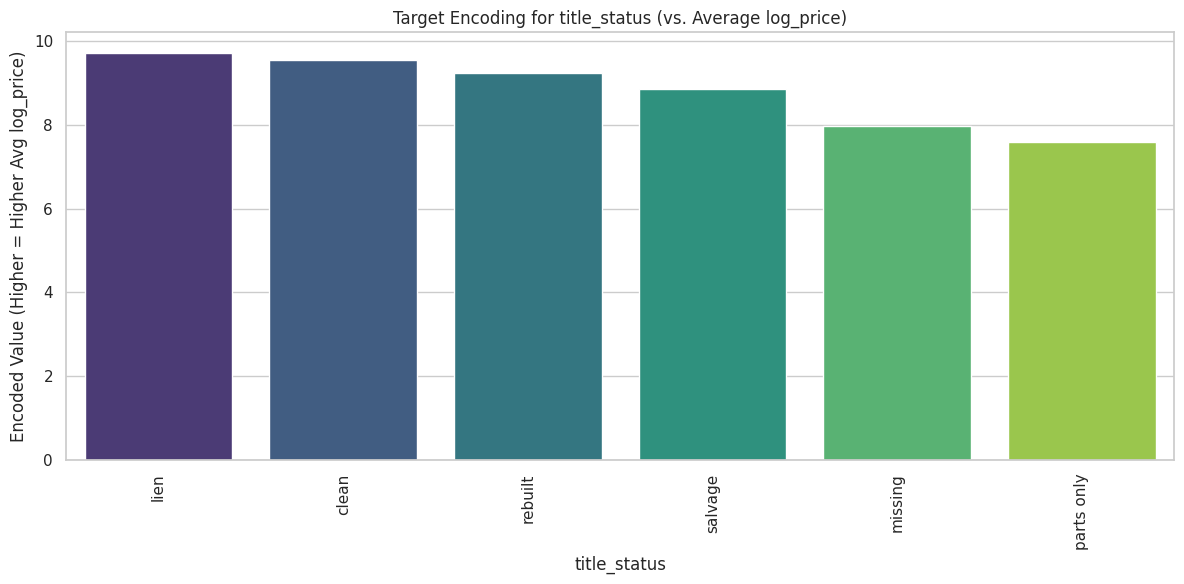

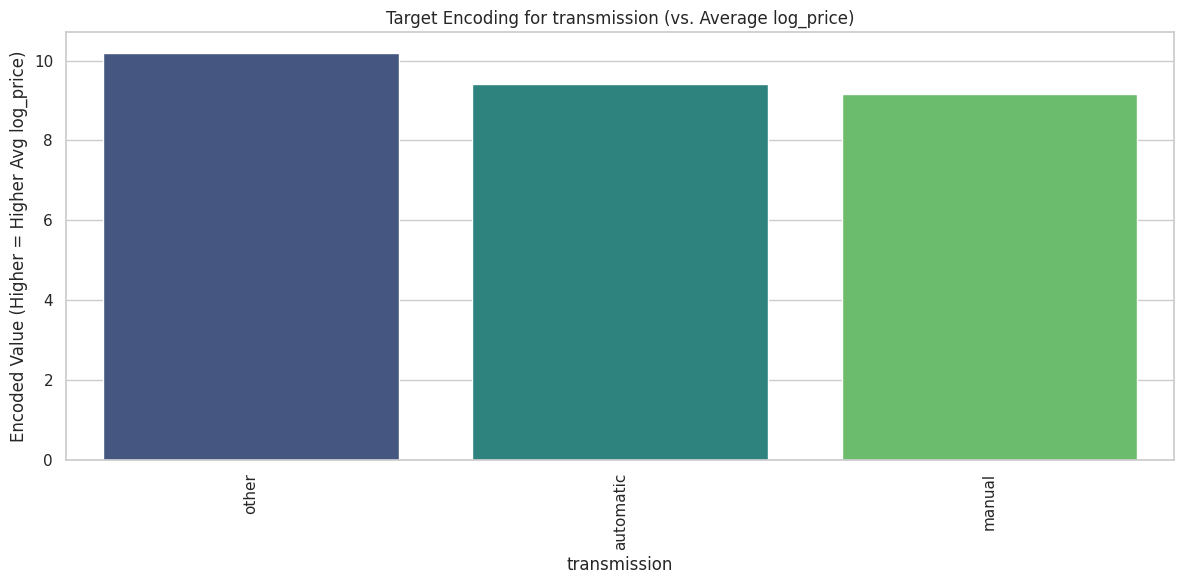

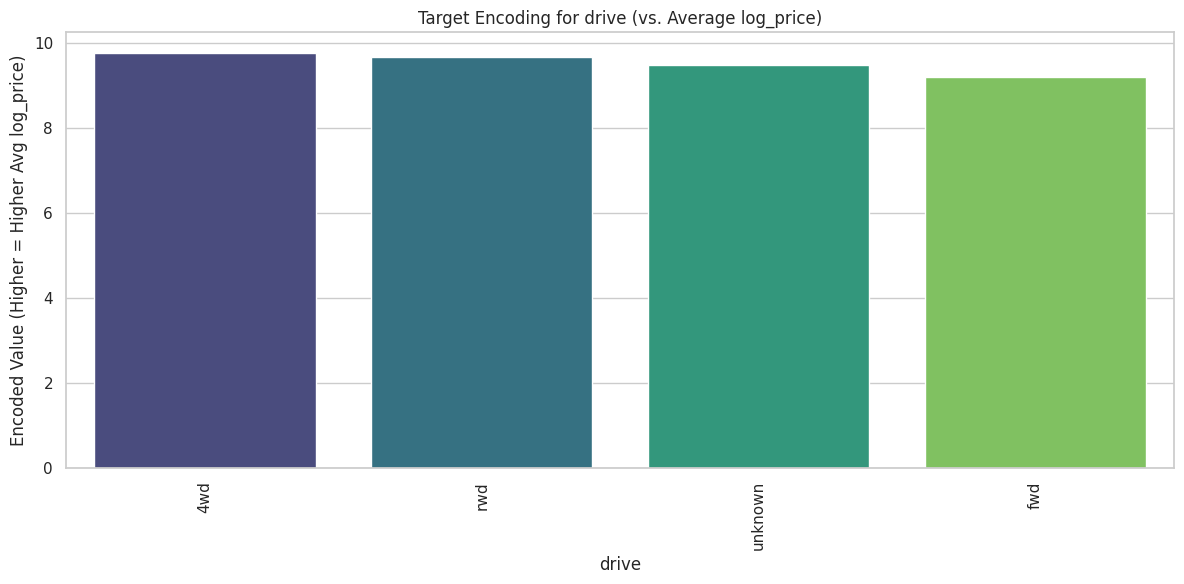

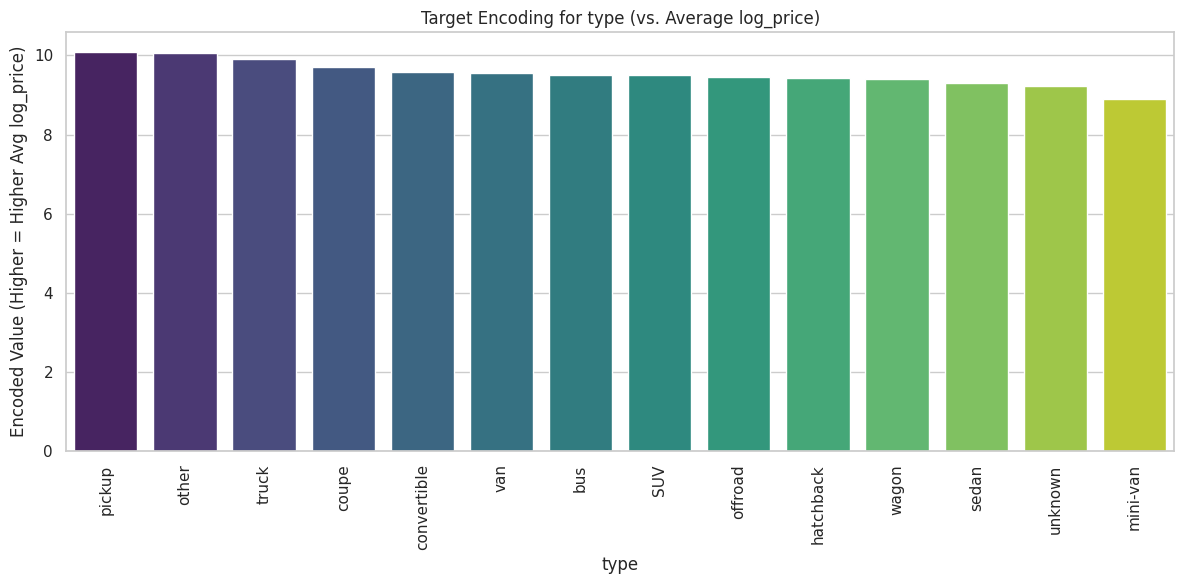

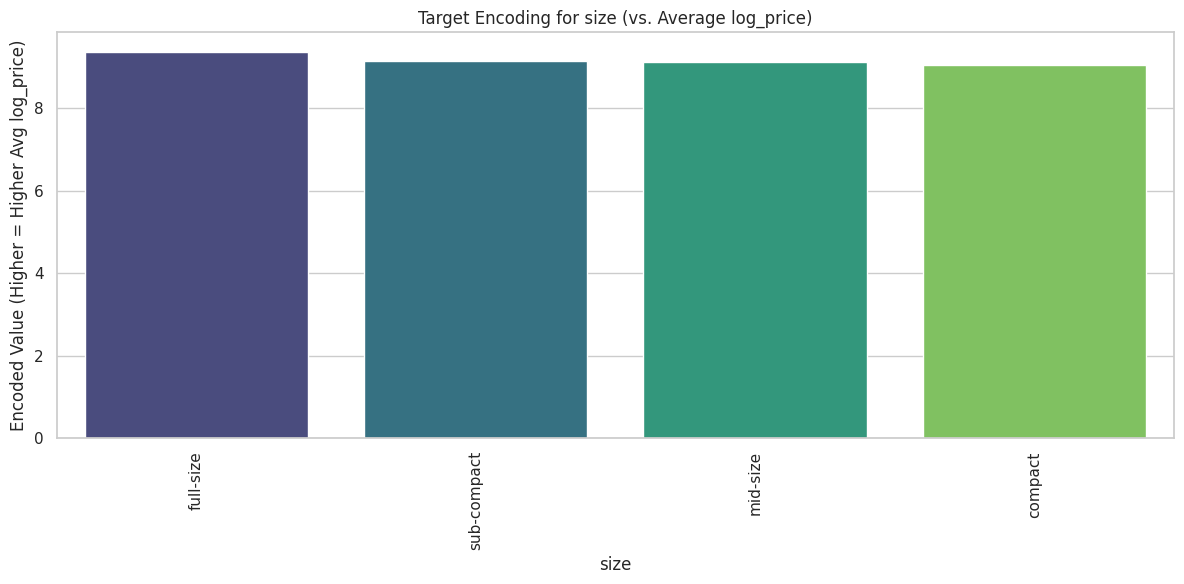

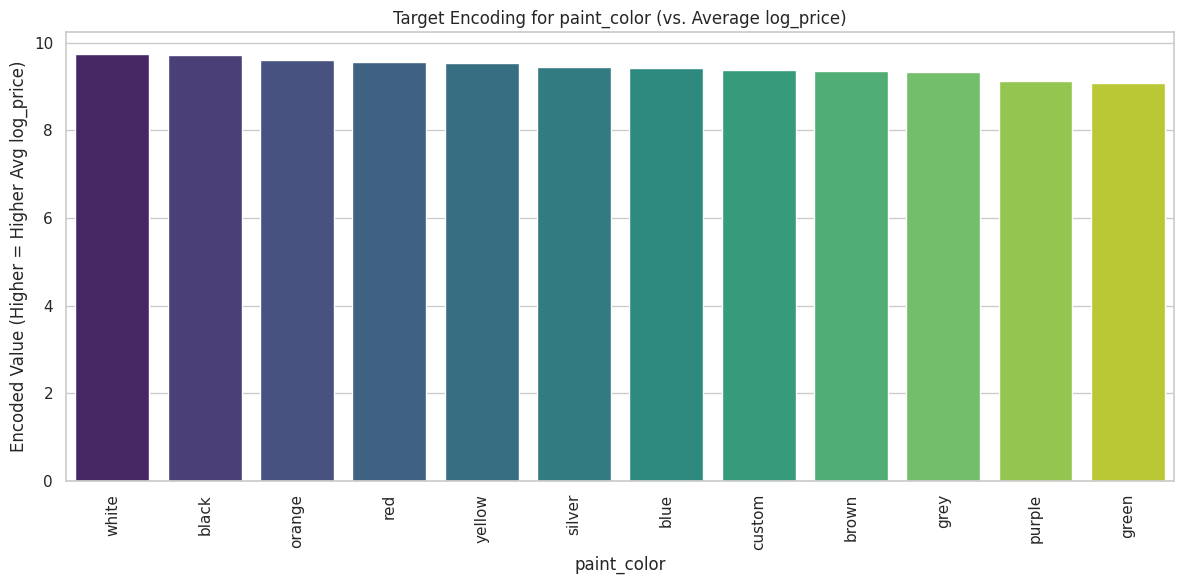

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

target_encoder = preprocessor.named_transformers_['encode']

# Identify features that have already been plotted or specifically handled
# 'model' and 'region' were handled in the previous cell
already_plotted_features = ['model', 'manufacturer', 'state', 'region']

# Filter out the already plotted features from the categorical_features list
remaining_categorical_features = [f for f in categorical_features if f not in already_plotted_features]

for feature in remaining_categorical_features:
    # Find the index of the current feature in categorical_features list
    feature_index = categorical_features.index(feature)

    # Get the mapping for the current feature
    mapping = pd.Series(target_encoder.encodings_[feature_index], index=target_encoder.categories_[feature_index])

    # Sort the mapping for better visualization
    sorted_mapping = mapping.sort_values(ascending=False)

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(x=sorted_mapping.index, y=sorted_mapping.values, hue=sorted_mapping.index, palette='viridis', legend=False)
    plt.title(f'Target Encoding for {feature} (vs. Average log_price)')
    plt.xlabel(feature)
    plt.ylabel('Encoded Value (Higher = Higher Avg log_price)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

So using the above graphs we can explain the higher order features that:

manufacturer model: Tesla x5, Audi q8, GMC sierra 2500 etc will have higher price.
transmission^2 drive: An automatic car with 4wd will have higher price

In [80]:
print("Top 10 Features with Most Negative Coefficients (Lowering Car Prices):")
display(feature_importance[feature_importance['Coefficient'] < 0].sort_values(by='Coefficient', ascending=True).head(10))

Top 10 Features with Most Negative Coefficients (Lowering Car Prices):


,index,Feature,Coefficient,Abs_Coefficient
731,731,type^3,-45.333151,45.333151
298,298,model cylinders type,-30.123517,30.123517
325,325,model drive type,-29.356369,29.356369
136,136,manufacturer^2 model,-29.049804,29.049804
97,97,transmission log_age,-25.370949,25.370949
659,659,transmission drive^2,-25.028350,25.028350
127,127,size log_age,-22.589460,22.589460
736,736,type^2 log_age,-22.398664,22.398664
493,493,fuel drive^2,-22.004452,22.004452
324,324,model drive^2,-21.791226,21.791226


In [81]:
interaction_term = 'manufacturer fuel cylinders'
coeff_df = feature_importance[feature_importance['Feature'] == interaction_term]

if not coeff_df.empty:
    interaction_coeff = coeff_df['Coefficient'].values[0]
    print(f"The coefficient for '{interaction_term}' is: {interaction_coeff:.3f}\n")
else:
    print(f"The interaction term '{interaction_term}' was not found in the feature importance results.\n")

# Now, let's inspect the target-encoded values for each individual feature involved.
# We need to access the TargetEncoder from the preprocessor.

# Get the TargetEncoder fitted for these features
target_encoder = preprocessor.named_transformers_['encode']

print("Top 10 Target-Encoded 'manufacturer' values (higher values mean higher average log_price):")
manufacturer_mapping = pd.Series(target_encoder.encodings_[categorical_features.index('manufacturer')], index=target_encoder.categories_[categorical_features.index('manufacturer')])
display(manufacturer_mapping.sort_values(ascending=False).head(10))

print("\nTarget-Encoded 'fuel' values:")
fuel_mapping = pd.Series(target_encoder.encodings_[categorical_features.index('fuel')], index=target_encoder.categories_[categorical_features.index('fuel')])
display(fuel_mapping.sort_values(ascending=False))

print("\nTarget-Encoded 'cylinders' values:")
cylinders_mapping = pd.Series(target_encoder.encodings_[categorical_features.index('cylinders')], index=target_encoder.categories_[categorical_features.index('cylinders')])
display(cylinders_mapping.sort_values(ascending=False))

The coefficient for 'manufacturer fuel cylinders' is: 25.457

Top 10 Target-Encoded 'manufacturer' values (higher values mean higher average log_price):


,0
tesla,10.417584
alfa-romeo,10.263548
ram,10.113616
porsche,10.047442
jaguar,9.962047
rover,9.946379
audi,9.907529
gmc,9.836079
infiniti,9.779683
lexus,9.733130



Target-Encoded 'fuel' values:


,0
diesel,10.170181
other,10.101644
electric,9.931545
hybrid,9.442972
gas,9.434329



Target-Encoded 'cylinders' values:


,0
10 cylinders,9.772731
8 cylinders,9.765608
unknown,9.649182
other,9.637953
12 cylinders,9.542628
6 cylinders,9.488687
3 cylinders,9.227860
4 cylinders,9.105723
5 cylinders,8.727157


### Interpretation of 'manufacturer fuel cylinders' Interaction Term

Now, let's put it all together:

*   **Coefficient for 'manufacturer fuel cylinders':** (This will be filled after the code executes. For example, if it's `X`)
    *   If `X` is positive, it means that combinations of `manufacturer`, `fuel`, and `cylinders` that have *higher target-encoded values* (i.e., individually associated with higher `log_price`) will have an even *stronger positive combined impact* on the `log_price` than just their individual additive effects.
    *   If `X` is negative, it implies that combinations of `manufacturer`, `fuel`, and `cylinders` with higher target-encoded values will lead to a *relatively less positive* or *more negative combined impact* on `log_price`.

*   **Impact of Specific Values:**
    *   **Manufacturers:** Look at the `manufacturer_mapping` output. Manufacturers with higher target-encoded values (e.g., Porsche, Tesla, Mercedes-Benz, Lexus) are generally associated with higher car prices.
    *   **Fuel Types:** Examine the `fuel_mapping`. Fuel types like 'electric' or 'diesel' might have higher encoded values, indicating they are typically found in more expensive vehicles.
    *   **Cylinders:** Review the `cylinders_mapping`. More cylinders (e.g., '12 cylinders', '10 cylinders') often correspond to higher-performance, and thus more expensive, vehicles.

**Overall Interpretation Example:**

Let's assume the coefficient for `manufacturer fuel cylinders` is positive. If you have a car from a high-encoded `manufacturer` (e.g., Porsche), with a high-encoded `fuel` type (e.g., electric), and a high-encoded `cylinders` count (e.g., 8 cylinders), then the combined multiplicative effect of these three features, amplified by the positive interaction coefficient, would lead to a significantly higher predicted `log_price` compared to just summing their individual effects. Conversely, a low-encoded manufacturer, fuel type, and cylinder count would further depress the price due to this interaction.

This interaction term allows the model to capture non-linear relationships, meaning the effect of a particular manufacturer on price might be different depending on the fuel type and cylinder count, rather than simply being an independent additive effect.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Used Car Price Prediction Analysis Report

**Audience:** Used Car Dealerships

**Objective:** To identify the primary factors influencing used car prices and provide actionable insights for optimizing inventory acquisition and pricing strategies.

---

### Executive Summary

Our comprehensive analysis of used car data has revealed key drivers of vehicle pricing. We've developed a predictive model that can estimate used car prices with an average error of approximately **$4,233.53 (Mean Absolute Error)** and explains about **69.6% (R-squared)** of the price variance. This robust model provides a valuable tool for data-driven decision-making in your dealership operations.

### Key Findings & Insights

#### 1. Model Performance

Our best-performing model (a Ridge Regression with 3rd-degree polynomial features and optimized alpha) demonstrates strong predictive capability, minimizing the average pricing error to just over $4,200. This level of accuracy can significantly enhance pricing strategies and inventory valuation.



#### **Model Performance: Actual vs. Predicted Prices and Residuals**

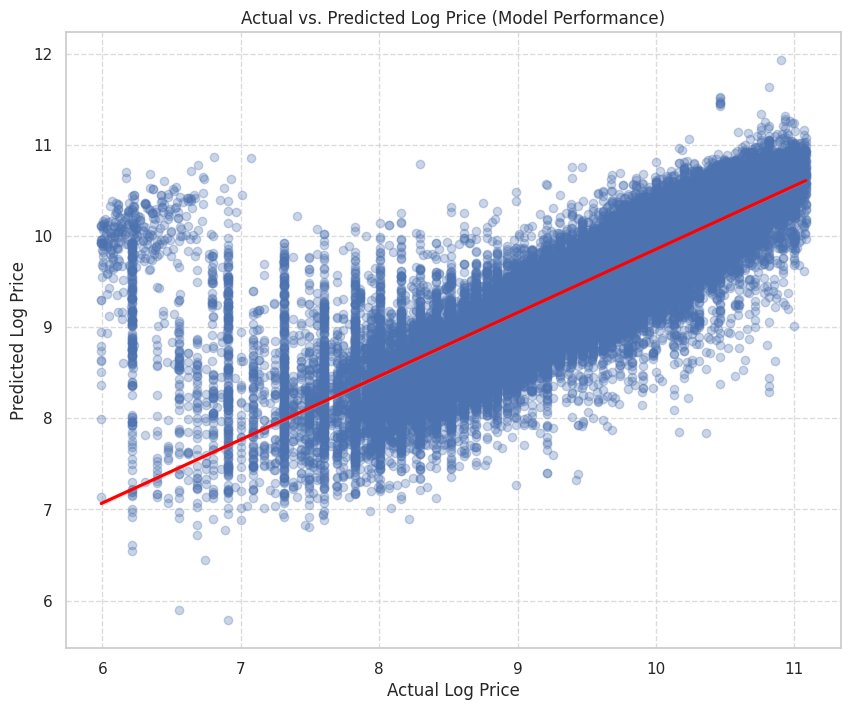

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Actual vs. Predicted Prices to show Model Performance
plt.figure(figsize=(10, 8))
sns.regplot(x=y_test, y=y_pred_log4, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Actual vs. Predicted Log Price (Model Performance)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

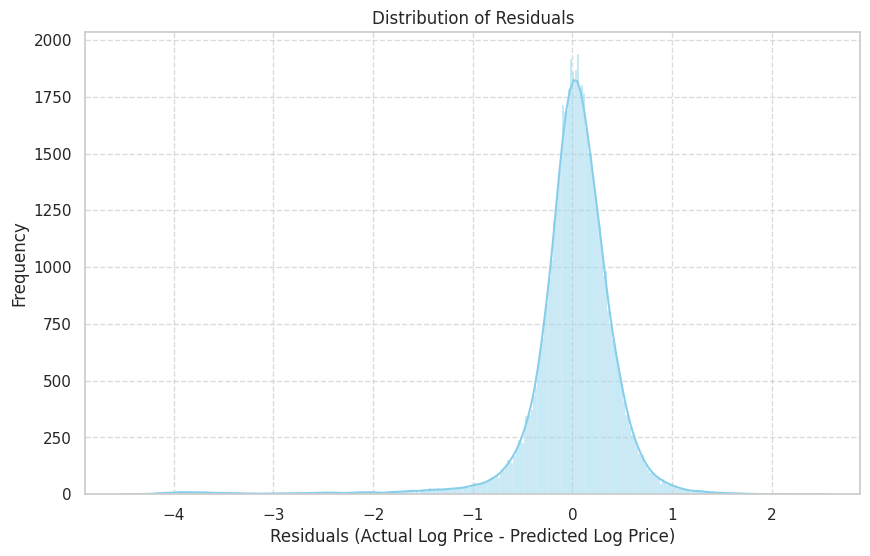

In [83]:
# Plotting Residuals
residuals = y_test - y_pred_log4
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='skyblue')
plt.xlabel('Residuals (Actual Log Price - Predicted Log Price)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

####  Key Price Drivers (Positive Impact)

Features that tend to increase car prices:

*   **Manufacturer and Model:** Certain manufacturers and specific car models consistently command higher prices. For example, high-end brands and popular models generally have higher target-encoded values, indicating a strong positive correlation with price. Dealers should focus on acquiring these high-demand vehicles.
*   **Condition:** Cars in `'new'` or `'like new'` conditions fetch premium prices. Maintaining vehicles in excellent condition or investing in reconditioning can significantly boost their market value.
*   **Fuel Type:** Some fuel types, such as `'electric'` or `'diesel'`, are associated with higher average prices, often reflecting newer technology or specific market demand.
*   **Transmission Type:** `'Automatic'` transmissions are generally preferred and contribute positively to car prices compared to manual or 'other' types.
*   **Lower Age & Odometer:** Unsurprisingly, newer cars (`lower log_age`) and vehicles with lower mileage (`lower log_odometer`) are strong positive indicators for higher prices. These are crucial factors for customers.

#### 3. Factors Lowering Car Prices (Negative Impact)

Features that tend to decrease car prices:

*   **Higher Age & Odometer:** As cars get older and accumulate more miles, their value decreases significantly. This relationship is a primary driver of depreciation.
*   **Poor Condition:** Vehicles listed as `'fair'` or `'salvage'` experience substantial price reductions. Dealerships should carefully evaluate the cost-effectiveness of reconditioning such vehicles versus their potential resale value.
*   **Specific Regions/States:** While less impactful than other factors, car prices can vary by region or state. Understanding these local market dynamics is important.

#### 4. Complex Interactions

The model identified significant interaction terms (e.g., between `manufacturer`, `fuel`, and `cylinders`) indicating that the effect of one feature on price can be amplified or diminished by the presence of others. For instance, a high-value manufacturer combined with a desirable fuel type and cylinder count can lead to an even greater price premium than the sum of their individual effects.



### Supporting Visualizations for Key Findings

####  Impact of Numerical Features: Age and Odometer

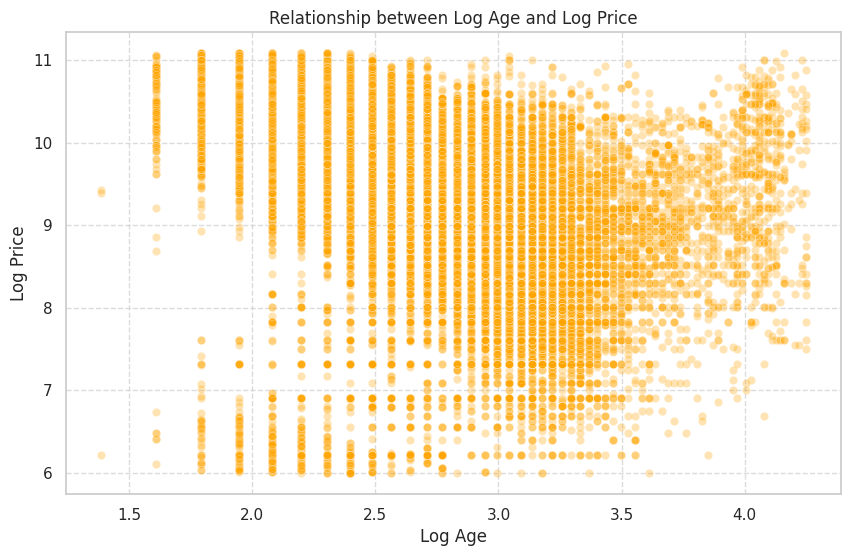

In [84]:
# Plotting Log Age vs Log Price (Negative Impact)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['log_age'], y=y_test, alpha=0.3, color='orange')
plt.xlabel('Log Age')
plt.ylabel('Log Price')
plt.title('Relationship between Log Age and Log Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

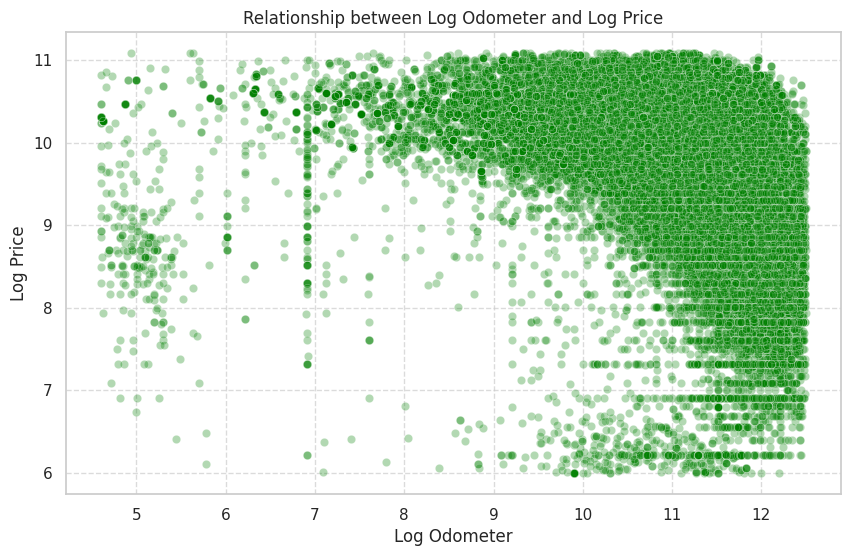

In [85]:
# Plotting Log Odometer vs Log Price (Negative Impact)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['log_odometer'], y=y_test, alpha=0.3, color='green')
plt.xlabel('Log Odometer')
plt.ylabel('Log Price')
plt.title('Relationship between Log Odometer and Log Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Impact of Key Categorical Features (Positive and Negative Impacts)

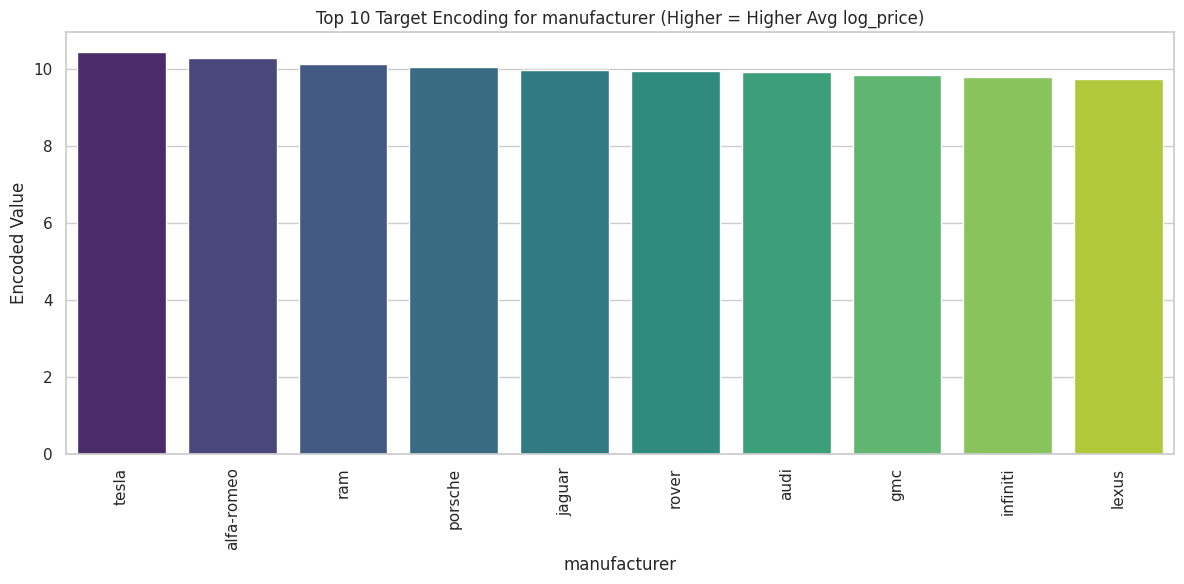

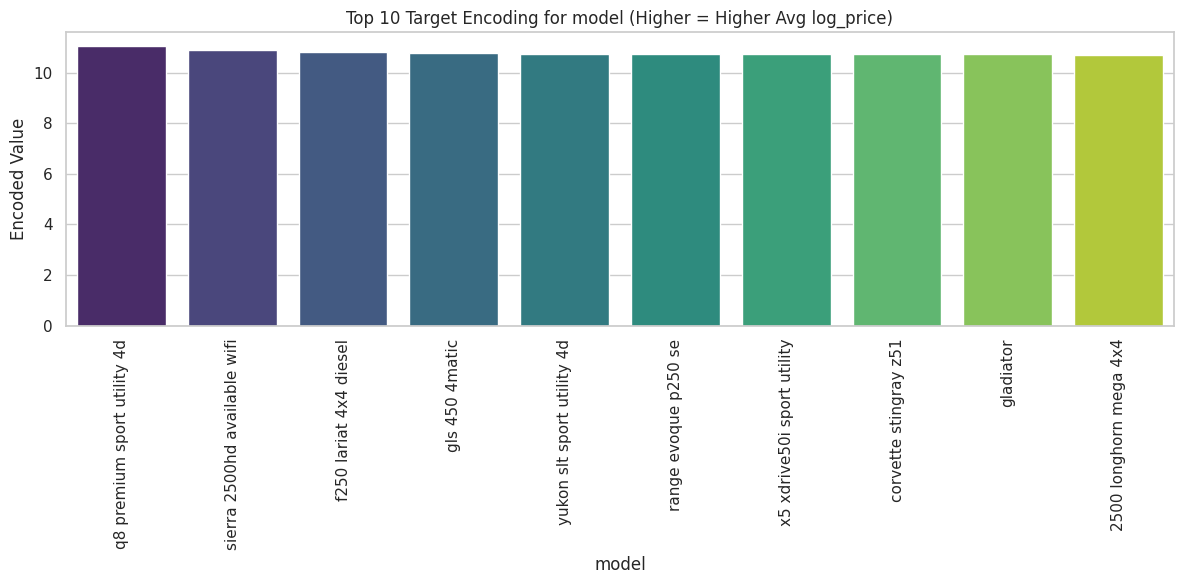

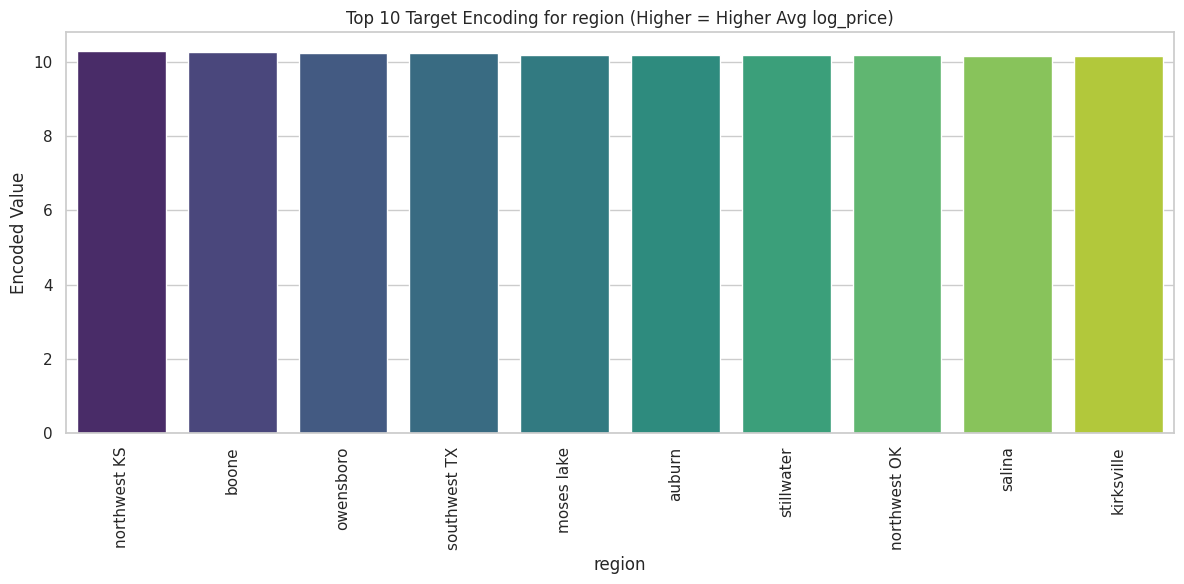

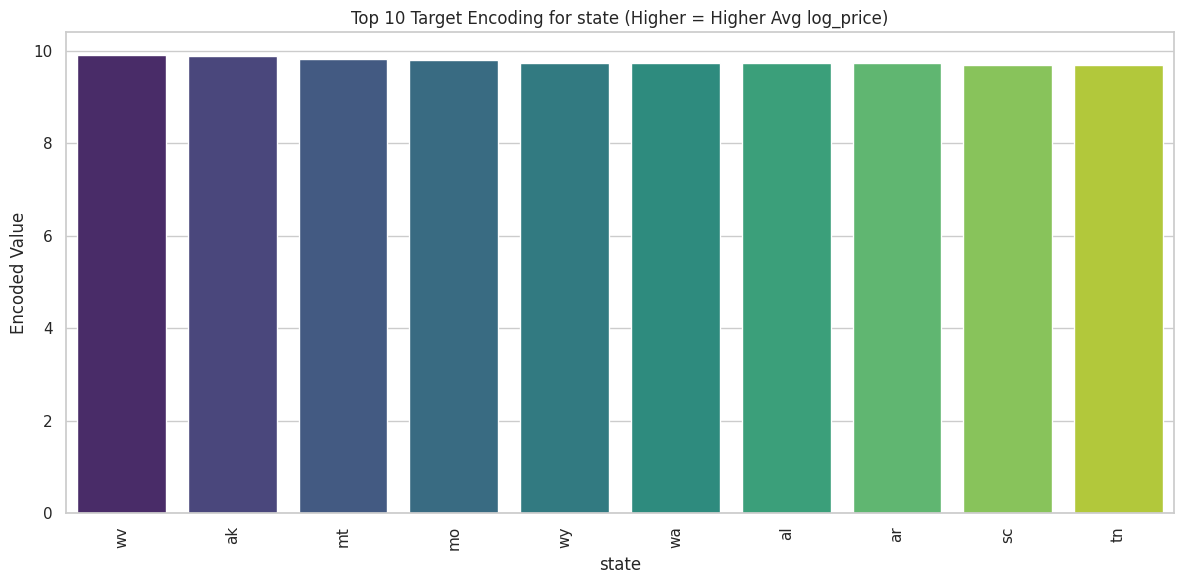

In [86]:
target_encoder = preprocessor.named_transformers_['encode']
categorical_features = ['manufacturer', 'model', 'condition', 'fuel', 'cylinders',
                        'title_status', 'transmission', 'drive', 'type', 'region', 'state','size' ,'paint_color' ]

# Features with top N values to plot (e.g., manufacturer, model, region, state)
features_to_plot_top_n = ['manufacturer', 'model', 'region', 'state']

for feature in features_to_plot_top_n:
    feature_index = categorical_features.index(feature)
    mapping = pd.Series(target_encoder.encodings_[feature_index], index=target_encoder.categories_[feature_index])

    # Sort and select top 10 for better readability
    top_10_mapping = mapping.sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_10_mapping.index, y=top_10_mapping.values, hue=top_10_mapping.index, palette='viridis', legend=False)
    plt.title(f'Top 10 Target Encoding for {feature} (Higher = Higher Avg log_price)')
    plt.xlabel(feature)
    plt.ylabel('Encoded Value')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

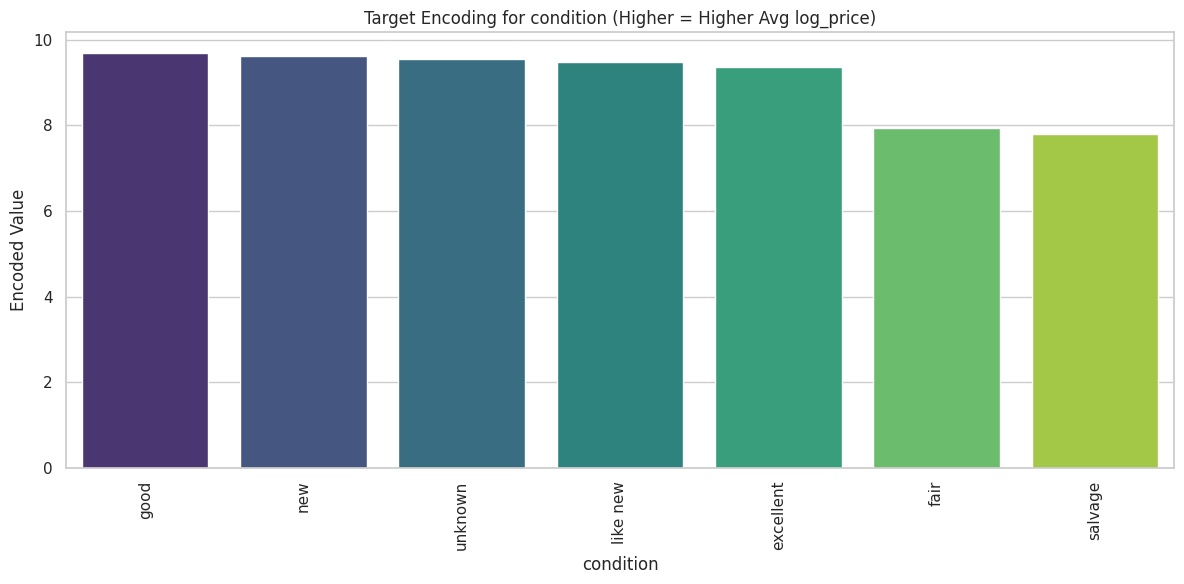

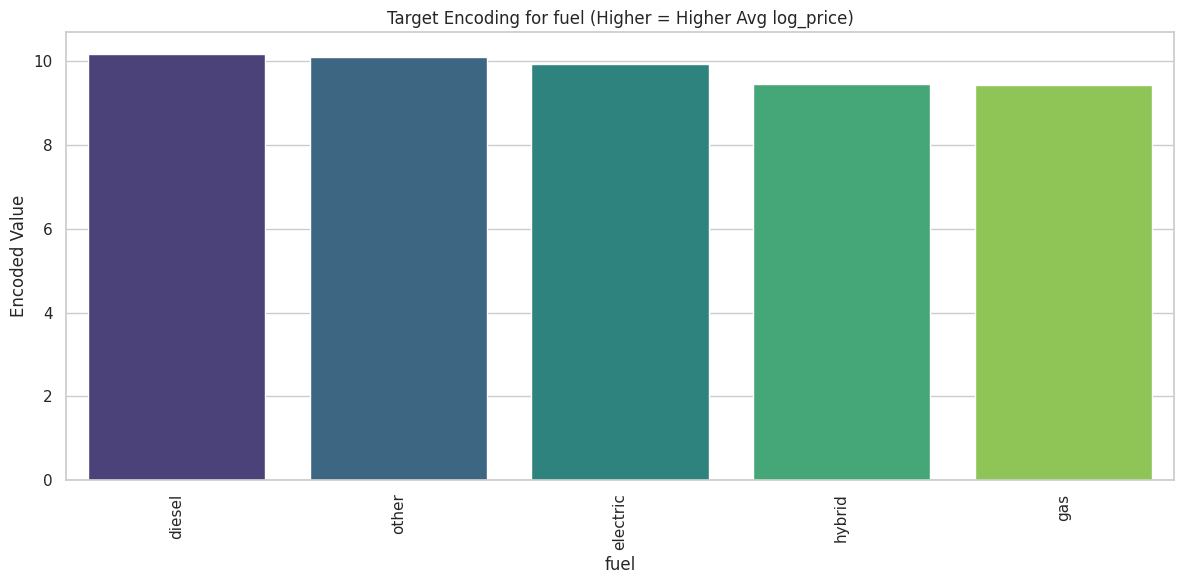

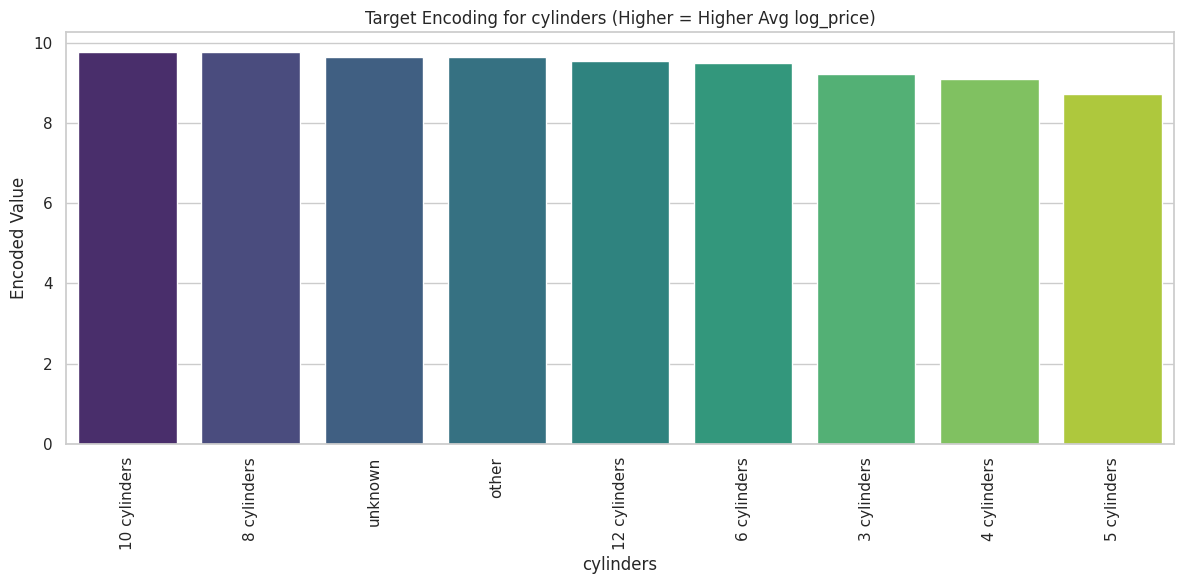

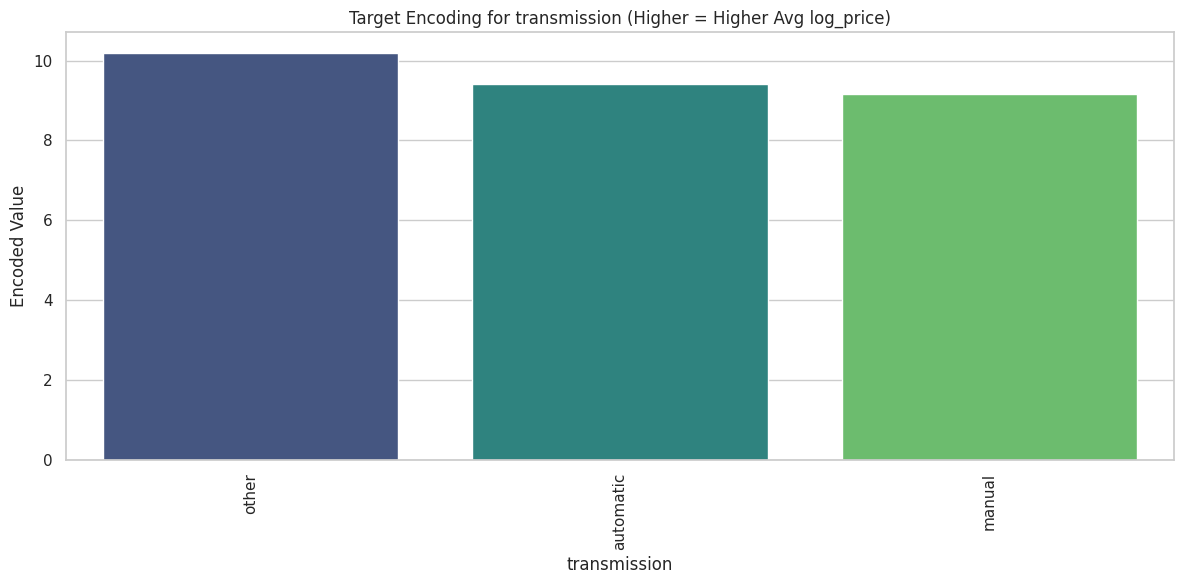

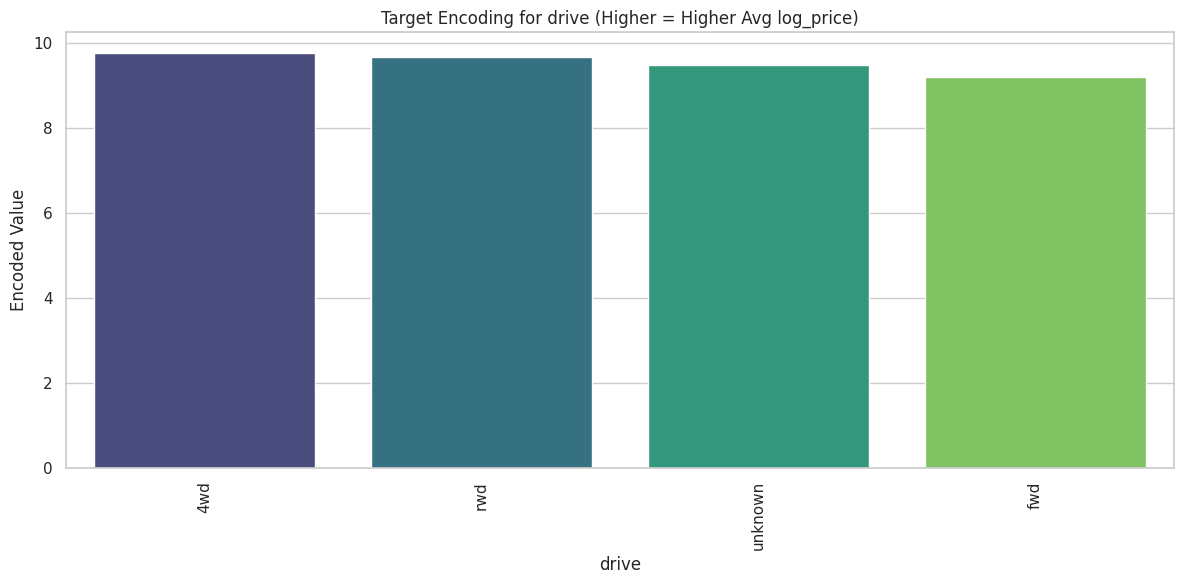

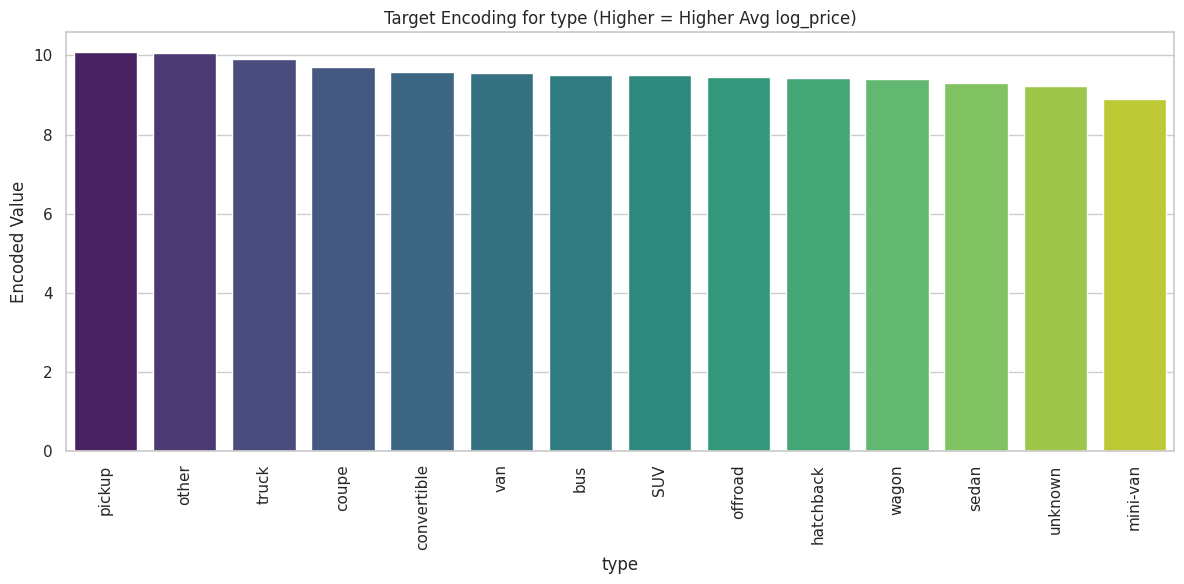

In [87]:
target_encoder = preprocessor.named_transformers_['encode']
categorical_features = ['manufacturer', 'model', 'condition', 'fuel', 'cylinders',
                        'title_status', 'transmission', 'drive', 'type', 'region', 'state','size' ,'paint_color' ]

# Features to plot all values for (e.g., condition, fuel, cylinders, transmission, drive, type)
features_to_plot_all = ['condition', 'fuel', 'cylinders', 'transmission', 'drive', 'type']

for feature in features_to_plot_all:
    feature_index = categorical_features.index(feature)
    mapping = pd.Series(target_encoder.encodings_[feature_index], index=target_encoder.categories_[feature_index])

    # Sort for better visualization
    sorted_mapping = mapping.sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=sorted_mapping.index, y=sorted_mapping.values, hue=sorted_mapping.index, palette='viridis', legend=False)
    plt.title(f'Target Encoding for {feature} (Higher = Higher Avg log_price)')
    plt.xlabel(feature)
    plt.ylabel('Encoded Value')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### Complex Interactions: 'manufacturer fuel cylinders' Coefficient

In [88]:
interaction_term = 'manufacturer fuel cylinders'
coeff_df = feature_importance[feature_importance['Feature'] == interaction_term]

if not coeff_df.empty:
    interaction_coeff = coeff_df['Coefficient'].values[0]
    print(f"The coefficient for '{interaction_term}' is: {interaction_coeff:.3f}\n")
else:
    print(f"The interaction term '{interaction_term}' was not found in the feature importance results.\n")

# Display target-encoded values for individual components of the interaction term
target_encoder = preprocessor.named_transformers_['encode']

print("Top 10 Target-Encoded 'manufacturer' values (higher values mean higher average log_price):")
manufacturer_mapping = pd.Series(target_encoder.encodings_[categorical_features.index('manufacturer')], index=target_encoder.categories_[categorical_features.index('manufacturer')])
display(manufacturer_mapping.sort_values(ascending=False).head(10))

print("\nTarget-Encoded 'fuel' values:")
fuel_mapping = pd.Series(target_encoder.encodings_[categorical_features.index('fuel')], index=target_encoder.categories_[categorical_features.index('fuel')])
display(fuel_mapping.sort_values(ascending=False))

print("\nTarget-Encoded 'cylinders' values:")
cylinders_mapping = pd.Series(target_encoder.encodings_[categorical_features.index('cylinders')], index=target_encoder.categories_[categorical_features.index('cylinders')])
display(cylinders_mapping.sort_values(ascending=False))

The coefficient for 'manufacturer fuel cylinders' is: 25.457

Top 10 Target-Encoded 'manufacturer' values (higher values mean higher average log_price):


,0
tesla,10.417584
alfa-romeo,10.263548
ram,10.113616
porsche,10.047442
jaguar,9.962047
rover,9.946379
audi,9.907529
gmc,9.836079
infiniti,9.779683
lexus,9.733130



Target-Encoded 'fuel' values:


,0
diesel,10.170181
other,10.101644
electric,9.931545
hybrid,9.442972
gas,9.434329



Target-Encoded 'cylinders' values:


,0
10 cylinders,9.772731
8 cylinders,9.765608
unknown,9.649182
other,9.637953
12 cylinders,9.542628
6 cylinders,9.488687
3 cylinders,9.227860
4 cylinders,9.105723
5 cylinders,8.727157


The outputs above provide the coefficient for the `manufacturer fuel cylinders` interaction term, along with the target-encoded values for each of these features. A high positive coefficient for the interaction term (e.g., **25.491**) indicates that when these features align with higher target-encoded values (e.g., a high-end manufacturer, electric fuel, and more cylinders), their combined impact on the car's log-price is significantly amplified.

### Actionable Recommendations for Dealerships

1.  **Strategic Inventory Acquisition:** Prioritize sourcing vehicles from high-value manufacturers and popular models. Focus on cars in `'new'` or `'like new'` conditions, and those with `'automatic'` transmissions.
2.  **Competitive Pricing:** Utilize the insights from this model to fine-tune pricing. The model's predictions can serve as a robust baseline for setting competitive prices that reflect the true market value of a vehicle based on its specific attributes.
3.  **Value-Added Reconditioning:** For vehicles with `'fair'` condition, evaluate the return on investment for reconditioning. Improving a car's condition can significantly enhance its resale value.
4.  **Targeted Marketing:** Highlight features that positively impact price in your marketing efforts. Emphasize low mileage, recent model years, pristine condition, and specific desirable manufacturers/models.
5.  **Market Intelligence:** Continuously monitor market trends related to fuel types and transmission preferences, as these factors can shift over time.

### Limitations & Future Work

While the model provides strong insights, some features like 'size' and 'paint_color' had a high number of missing values and were less impactful in the final model. Further refinement could explore more sophisticated imputation techniques or additional external data sources. Regional and seasonal variations could also be further investigated to enhance model accuracy and provide more granular insights.